# Créez un assistant intelligent pour recommander des événements culturels

###
Enterprise Puls-Events souhaite tester un nouveau chatbot intelligent capable de répondre à des questions utilisateurs sur les événements culturels à venir, en s'appuyant sur un système RAG (Retrieval-Augmented Generation)

In [2]:
import sys
print(sys.executable)

C:\Users\amela\anaconda3\python.exe


In [4]:
!pip list

Package                            Version
---------------------------------- ------------------
aext-assistant                     4.1.0
aext-assistant-server              4.1.0
aext-core                          4.1.0
aext-core-server                   4.1.0
aext-panels                        4.1.0
aext-panels-server                 4.1.0
aext-project-filebrowser-server    4.1.0
aext-share-notebook                4.1.0
aext-share-notebook-server         4.1.0
aext-shared                        4.1.0
aext-toolbox                       4.1.0
aiobotocore                        2.12.3
aiohappyeyeballs                   2.4.0
aiohttp                            3.10.5
aioitertools                       0.7.1
aiosignal                          1.2.0
alabaster                          0.7.16
alembic                            1.13.3
altair                             5.5.0
anaconda-anon-usage                0.4.4
anaconda-catalogs                  0.2.0
anaconda-cli-base                  0.5

In [6]:
pip install faiss-cpu

Note: you may need to restart the kernel to use updated packages.


In [9]:
!pip install langchain-community

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("OK")

OK


In [13]:
import json
import re
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Outils système
import warnings

# RAG 
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

from transformers import AutoTokenizer, AutoModel
import torch

from sentence_transformers import SentenceTransformer

C:\Users\amela\AppData\Local\Temp\ipykernel_5692\2333631148.py:17: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [15]:
import faiss

print("FAISS OK")

FAISS OK


In [17]:
import langchain
print(langchain.__version__)

1.3.10


In [19]:
!pip install sentence-transformers numpy -q
print("Bibliotheques installees !")

Bibliotheques installees !


In [21]:
from sentence_transformers import SentenceTransformer

print("SentenceTransformer OK")

SentenceTransformer OK


In [23]:
pip install sentence-transformers faiss-cpu

Note: you may need to restart the kernel to use updated packages.


## Download des donnees

In [26]:
from pathlib import Path
import json

# Chemin vers le fichier JSON
data_path = Path("evenements-publics-openagenda.json")

# Vérification
print("Fichier trouvé :", data_path.exists())

# Chargement
with open(data_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# Aperçu
print(type(data))
print("Nombre d'éléments :", len(data) if hasattr(data, "__len__") else "N/A")

Fichier trouvé : True
<class 'list'>
Nombre d'éléments : 8305


In [28]:
from pprint import pprint

print(type(data))
print(type(data[0]))
pprint(data[0])

<class 'list'>
<class 'dict'>
{'accessibility': None,
 'accessibility_label_fr': None,
 'age_max': None,
 'age_min': None,
 'attendancemode': '{"id": 1, "label": {"fr": "Sur place", "en": "In situ", '
                   '"it": "In presenza", "es": "Desconnectad", "de": '
                   '"Offline", "br": "War al lec\\u2019h", "io": '
                   '"crwdns14266:0crwdne14266:0", "oc": "Sus pla\\u00e7a"}}',
 'canonicalurl': 'https://openagenda.com/semaine-des-metiers-du-tourisme/events/presentation-de-la-formation-charge-e-accueil-tourisme-et-loisirs-a-la-mfr-des-sables-dolonne',
 'category': None,
 'conditions_fr': None,
 'contributor_contactname': None,
 'contributor_contactnumber': None,
 'contributor_contactposition': None,
 'contributor_email': None,
 'contributor_organization': None,
 'country_fr': 'France (Métropole)',
 'daterange_fr': 'Mardi 18 mars, 09h00',
 'description_fr': 'Il vous sera présenté la formation chargé-e d’accueil '
                   'tourisme et loisirs

In [30]:
import json

print(json.dumps(data[0], indent=2, ensure_ascii=False)[:3000])

{
  "uid": "8231710",
  "slug": "presentation-de-la-formation-charge-e-accueil-tourisme-et-loisirs-a-la-mfr-des-sables-dolonne",
  "canonicalurl": "https://openagenda.com/semaine-des-metiers-du-tourisme/events/presentation-de-la-formation-charge-e-accueil-tourisme-et-loisirs-a-la-mfr-des-sables-dolonne",
  "title_fr": "PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL TOURISME ET LOISIRS A LA MFR DES SABLES D'OLONNE",
  "description_fr": "Il vous sera présenté la formation chargé-e d’accueil tourisme et loisirs .De plus, un employeur interviendra pour vous expliquer les compétences et les conditions de travail .Des entretiens seron...",
  "longdescription_fr": "<p>Il vous sera présenté la formation chargé-e d’accueil tourisme et loisirs .De plus, un employeur interviendra pour vous expliquer les compétences et les conditions de travail .Des entretiens seront possibles avec la formatrice pour la prochaine session de septembre en fin de matinée</p>\n<p>Il vous sera présenté la formation char

In [32]:
print(data[0].keys())

dict_keys(['uid', 'slug', 'canonicalurl', 'title_fr', 'description_fr', 'longdescription_fr', 'conditions_fr', 'keywords_fr', 'image', 'imagecredits', 'thumbnail', 'originalimage', 'updatedat', 'daterange_fr', 'firstdate_begin', 'firstdate_end', 'lastdate_begin', 'lastdate_end', 'timings', 'accessibility', 'accessibility_label_fr', 'location_uid', 'location_coordinates', 'location_name', 'location_address', 'location_district', 'location_insee', 'location_postalcode', 'location_city', 'location_department', 'location_region', 'location_countrycode', 'location_image', 'location_imagecredits', 'location_phone', 'location_website', 'location_links', 'location_tags', 'location_description_fr', 'location_access_fr', 'attendancemode', 'onlineaccesslink', 'status', 'age_min', 'age_max', 'originagenda_title', 'originagenda_uid', 'contributor_email', 'contributor_contactnumber', 'contributor_contactname', 'contributor_contactposition', 'contributor_organization', 'category', 'country_fr', 'regi

In [34]:
for event in data[:5]:
    print("="*80)
    print("Titre :", event["title_fr"])
    print("Ville :", event["location_city"])
    print("Date :", event["firstdate_begin"])

Titre : PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL TOURISME ET LOISIRS A LA MFR DES SABLES D'OLONNE
Ville : Les Sables-d'Olonne
Date : 2025-03-18T09:00:00+01:00
Titre : Information collective Transport
Ville : Lyon
Date : 2025-03-27T09:00:00+01:00
Titre : Jeudis de la formation- Venez rencontrer Geyser
Ville : Rennes
Date : 2025-09-04T11:00:00+02:00
Titre : Formez-vous près de chez vous, des entreprises vous attendent !
Ville : Fougères
Date : 2025-09-04T14:00:00+02:00
Titre : Préparation opérationnelle à l'emploi AUXILIA TP ADVF Assistant de vie et aux familles
Ville : Marseille
Date : 2025-09-04T14:30:00+02:00


In [36]:
print(data[0].keys())

dict_keys(['uid', 'slug', 'canonicalurl', 'title_fr', 'description_fr', 'longdescription_fr', 'conditions_fr', 'keywords_fr', 'image', 'imagecredits', 'thumbnail', 'originalimage', 'updatedat', 'daterange_fr', 'firstdate_begin', 'firstdate_end', 'lastdate_begin', 'lastdate_end', 'timings', 'accessibility', 'accessibility_label_fr', 'location_uid', 'location_coordinates', 'location_name', 'location_address', 'location_district', 'location_insee', 'location_postalcode', 'location_city', 'location_department', 'location_region', 'location_countrycode', 'location_image', 'location_imagecredits', 'location_phone', 'location_website', 'location_links', 'location_tags', 'location_description_fr', 'location_access_fr', 'attendancemode', 'onlineaccesslink', 'status', 'age_min', 'age_max', 'originagenda_title', 'originagenda_uid', 'contributor_email', 'contributor_contactnumber', 'contributor_contactname', 'contributor_contactposition', 'contributor_organization', 'category', 'country_fr', 'regi

In [38]:
# Affichage des données
print("=" * 50)
print("EVENTS")
print("=" * 50)

for event in data[:5]:
    print(event["title_fr"])

EVENTS
PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL TOURISME ET LOISIRS A LA MFR DES SABLES D'OLONNE
Information collective Transport
Jeudis de la formation- Venez rencontrer Geyser
Formez-vous près de chez vous, des entreprises vous attendent !
Préparation opérationnelle à l'emploi AUXILIA TP ADVF Assistant de vie et aux familles


In [40]:
import pandas as pd

# Conversion en DataFrame
df = pd.DataFrame(data)

print(f"\nNombre d'événements : {len(df):,}")
print(f"Nombre de colonnes : {len(df.columns)}")


Nombre d'événements : 8,305
Nombre de colonnes : 56


In [42]:
df = pd.DataFrame(data)

df.head()

,uid,slug,canonicalurl,title_fr,description_fr,longdescription_fr,conditions_fr,keywords_fr,image,imagecredits,...,originagenda_uid,contributor_email,contributor_contactnumber,contributor_contactname,contributor_contactposition,contributor_organization,category,country_fr,registration,links
0,8231710,presentation-de-la-formation-charge-e-accueil-...,https://openagenda.com/semaine-des-metiers-du-...,PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL ...,Il vous sera présenté la formation chargé-e d’...,<p>Il vous sera présenté la formation chargé-e...,None,"[Réunion d'information, #TousMobilisés, 1 jeun...",None,None,...,38495884,None,None,None,None,None,None,France (Métropole),"[{""type"": ""link"", ""value"": ""https://meseveneme...",None
1,30000010,information-collective-transport-1303272,https://openagenda.com/semaine-des-metiers-du-...,Information collective Transport,"Présentation des métiers du Transport, formati...","<p>Présentation des métiers du Transport, form...",None,"[Réunion d'information, La semaine du Tourisme...",None,None,...,38495884,None,None,None,None,None,None,France (Métropole),"[{""type"": ""link"", ""value"": ""https://meseveneme...",None
2,38505436,jeudis-de-la-formation-venez-rencontrer-geyser...,https://openagenda.com/francetravail/events/je...,Jeudis de la formation- Venez rencontrer Geyser,Participez à notre réunion d'information pour ...,<p>Participez à notre réunion d'information po...,None,[Découverte formation],None,None,...,38495884,None,None,None,None,None,None,France (Métropole),"[{""type"": ""link"", ""value"": ""https://meseveneme...",None
3,80149067,formez-vous-pres-de-chez-vous-des-entreprises-...,https://openagenda.com/francetravail/events/fo...,"Formez-vous près de chez vous, des entreprises...",Venez vous formez près de chez vous sur les mé...,<p>Venez vous formez près de chez vous sur les...,None,"[Découverte formation, Recrutement, Découverte...",None,None,...,38495884,None,None,None,None,None,None,France (Métropole),"[{""type"": ""link"", ""value"": ""https://meseveneme...",None
4,20754830,preparation-operationnelle-a-lemploi-auxilia-t...,https://openagenda.com/francetravail/events/pr...,Préparation opérationnelle à l'emploi AUXILIA ...,Information collective préalable au positionne...,<p>Information collective préalable au positio...,None,"[#TousMobilisés, 1 jeune 1 solution, Recrutem...",None,None,...,38495884,None,None,None,None,None,None,France (Métropole),"[{""type"": ""link"", ""value"": ""https://meseveneme...",None


In [44]:
print(df.shape)

(8305, 56)


In [46]:
for col in df.columns:
    print(col)

uid
slug
canonicalurl
title_fr
description_fr
longdescription_fr
conditions_fr
keywords_fr
image
imagecredits
thumbnail
originalimage
updatedat
daterange_fr
firstdate_begin
firstdate_end
lastdate_begin
lastdate_end
timings
accessibility
accessibility_label_fr
location_uid
location_coordinates
location_name
location_address
location_district
location_insee
location_postalcode
location_city
location_department
location_region
location_countrycode
location_image
location_imagecredits
location_phone
location_website
location_links
location_tags
location_description_fr
location_access_fr
attendancemode
onlineaccesslink
status
age_min
age_max
originagenda_title
originagenda_uid
contributor_email
contributor_contactnumber
contributor_contactname
contributor_contactposition
contributor_organization
category
country_fr
registration
links


## Missing values

In [49]:
# Calcul des valeurs manquantes
missing_stats = pd.DataFrame({
    "valeurs_manquantes": df.isnull().sum(),
    "pourcentage": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("pourcentage", ascending=False)

print("=" * 50)
print("VALEURS MANQUANTES PAR COLONNE")
print("=" * 50)

print(missing_stats[missing_stats["valeurs_manquantes"] > 0])

VALEURS MANQUANTES PAR COLONNE
                             valeurs_manquantes  pourcentage
age_min                                    8305       100.00
accessibility_label_fr                     8305       100.00
location_tags                              8305       100.00
location_description_fr                    8305       100.00
location_access_fr                         8305       100.00
location_links                             8305       100.00
location_image                             8305       100.00
age_max                                    8305       100.00
contributor_email                          8305       100.00
location_website                           8305       100.00
location_phone                             8305       100.00
imagecredits                               8305       100.00
location_imagecredits                      8305       100.00
contributor_contactnumber                  8305       100.00
conditions_fr                              8305       

In [51]:
print("=" * 70)
print("VALEURS MANQUANTES PAR COLONNE")
print("=" * 70)

for col in df.columns:
    nb = df[col].isna().sum()
    pct = round(nb / len(df) * 100, 2)

    if nb > 0:
        print(f"{col}")
        print(f"  Valeurs manquantes : {nb}")
        print(f"  Pourcentage       : {pct}%")
        print("-" * 70)

VALEURS MANQUANTES PAR COLONNE
conditions_fr
  Valeurs manquantes : 8305
  Pourcentage       : 100.0%
----------------------------------------------------------------------
image
  Valeurs manquantes : 4945
  Pourcentage       : 59.54%
----------------------------------------------------------------------
imagecredits
  Valeurs manquantes : 8305
  Pourcentage       : 100.0%
----------------------------------------------------------------------
thumbnail
  Valeurs manquantes : 4945
  Pourcentage       : 59.54%
----------------------------------------------------------------------
originalimage
  Valeurs manquantes : 4945
  Pourcentage       : 59.54%
----------------------------------------------------------------------
accessibility
  Valeurs manquantes : 8305
  Pourcentage       : 100.0%
----------------------------------------------------------------------
accessibility_label_fr
  Valeurs manquantes : 8305
  Pourcentage       : 100.0%
--------------------------------------------------

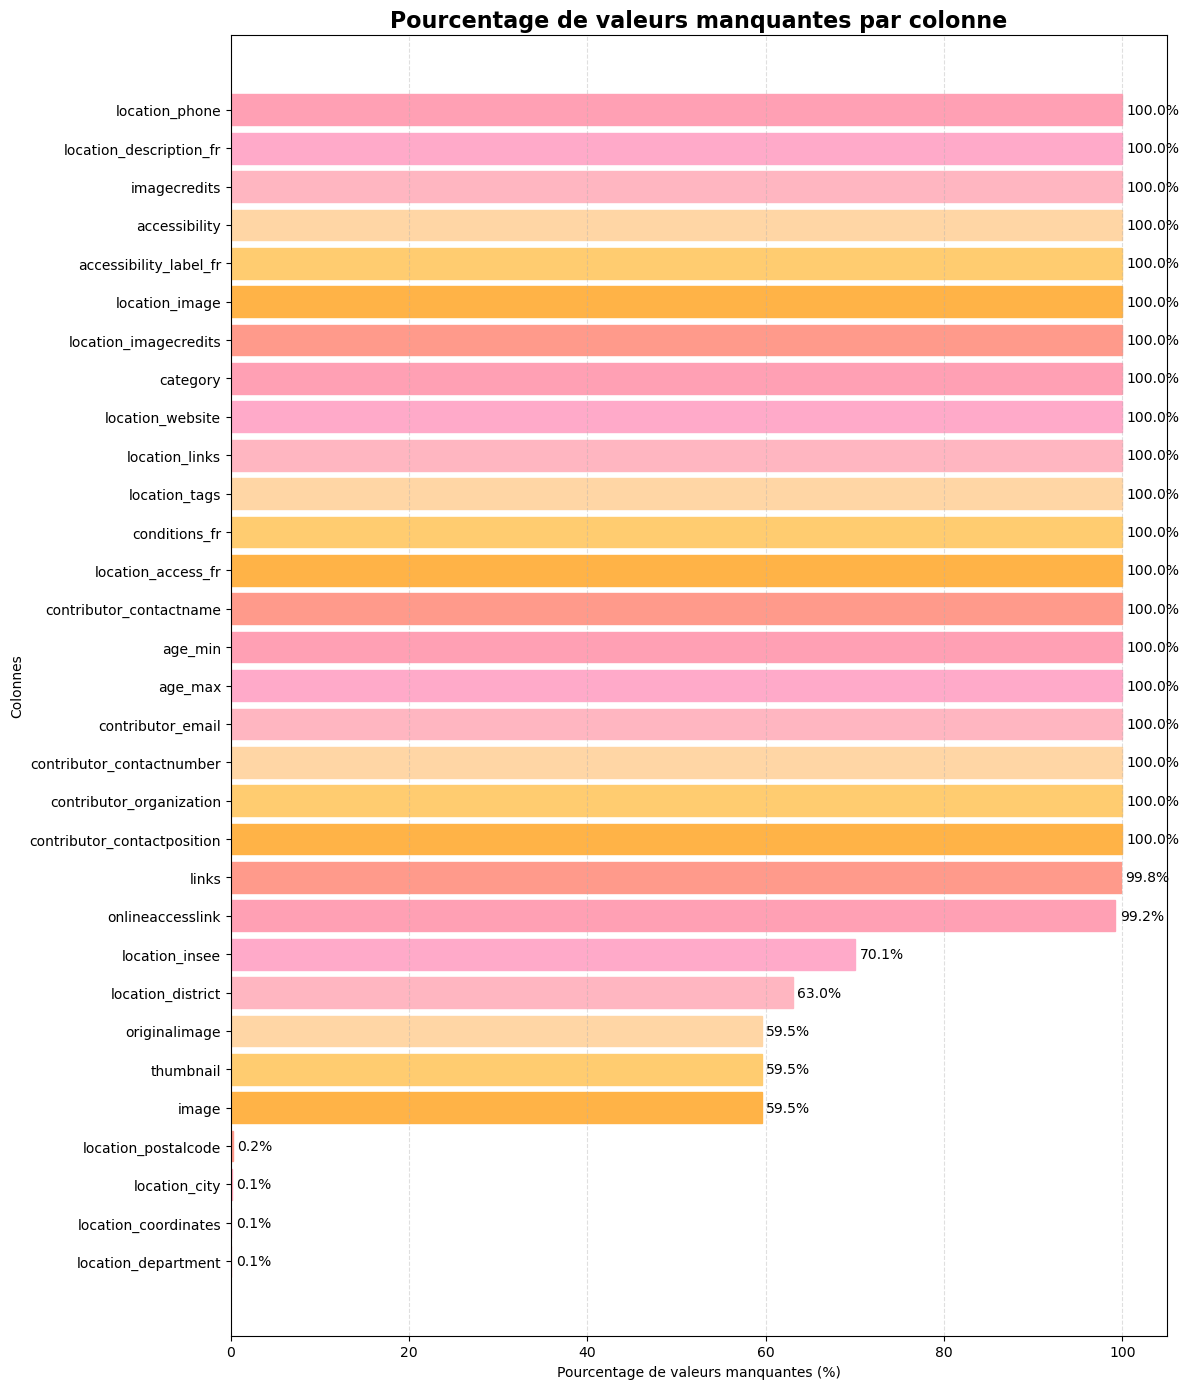

In [53]:
import matplotlib.pyplot as plt

# Calcul du pourcentage de valeurs manquantes
missing_pct = (df.isnull().sum() / len(df) * 100)

# Garder uniquement les colonnes avec des valeurs manquantes
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)

# Figure
plt.figure(figsize=(12, 14))

# Barres horizontales
bars = plt.barh(
    missing_pct.index,
    missing_pct.values
)

# Ajouter les pourcentages
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center"
    )

plt.title(
    "Pourcentage de valeurs manquantes par colonne",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pourcentage de valeurs manquantes (%)")
plt.ylabel("Colonnes")

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Couleurs dégradées rose → orange
colors = [
    "#FFB6C1", "#FFAAC9", "#FFA0B4", "#FF9A8B",
    "#FFB347", "#FFCC70", "#FFD6A5"
]

for i, bar in enumerate(bars):
    bar.set_color(colors[i % len(colors)])

plt.tight_layout()
plt.show()

### RAG 

In [56]:
# Pourcentage de valeurs présentes
completeness = (
    (1 - df.isnull().sum() / len(df)) * 100
).sort_values(ascending=False)

print(completeness)

uid                            100.000000
slug                           100.000000
location_region                100.000000
location_address               100.000000
location_name                  100.000000
location_uid                   100.000000
location_countrycode           100.000000
attendancemode                 100.000000
timings                        100.000000
lastdate_end                   100.000000
lastdate_begin                 100.000000
firstdate_end                  100.000000
firstdate_begin                100.000000
daterange_fr                   100.000000
updatedat                      100.000000
status                         100.000000
originagenda_title             100.000000
originagenda_uid               100.000000
country_fr                     100.000000
keywords_fr                    100.000000
registration                   100.000000
longdescription_fr             100.000000
description_fr                 100.000000
title_fr                       100

In [58]:
rag_columns = [
    "uid",
    "title_fr",
    "description_fr",
    "longdescription_fr",
    "keywords_fr",
    "location_city",
    "location_department",
    "location_region",
    "firstdate_begin",
    "firstdate_end",
    "canonicalurl"
]

df_rag = df[rag_columns]

In [60]:
print("=" * 60)
print("DÉTAIL DES CHAMPS ESSENTIELS (RAG)")
print("=" * 60)

completeness_data = []

for field in rag_columns: 
    if field in df.columns:
        non_null = df[field].notna().sum()
        pct = non_null / len(df) * 100

        completeness_data.append({
            "champ": field,
            "complet": non_null,
            "pourcentage": round(pct, 2)
        })

        print(f"{field:<25} {non_null:>6,}/{len(df):,} ({pct:.2f}%)")

    else:
        print(f"{field:<25} COLONNE ABSENTE ❌")

DÉTAIL DES CHAMPS ESSENTIELS (RAG)
uid                        8,305/8,305 (100.00%)
title_fr                   8,305/8,305 (100.00%)
description_fr             8,305/8,305 (100.00%)
longdescription_fr         8,305/8,305 (100.00%)
keywords_fr                8,305/8,305 (100.00%)
location_city              8,298/8,305 (99.92%)
location_department        8,299/8,305 (99.93%)
location_region            8,305/8,305 (100.00%)
firstdate_begin            8,305/8,305 (100.00%)
firstdate_end              8,305/8,305 (100.00%)
canonicalurl               8,305/8,305 (100.00%)


In [62]:
import pandas as pd

completeness_df = pd.DataFrame(completeness_data)
completeness_df.sort_values("pourcentage", ascending=False)

,champ,complet,pourcentage
0,uid,8305,100.00
1,title_fr,8305,100.00
2,description_fr,8305,100.00
3,longdescription_fr,8305,100.00
4,keywords_fr,8305,100.00
7,location_region,8305,100.00
8,firstdate_begin,8305,100.00
9,firstdate_end,8305,100.00
10,canonicalurl,8305,100.00
6,location_department,8299,99.93


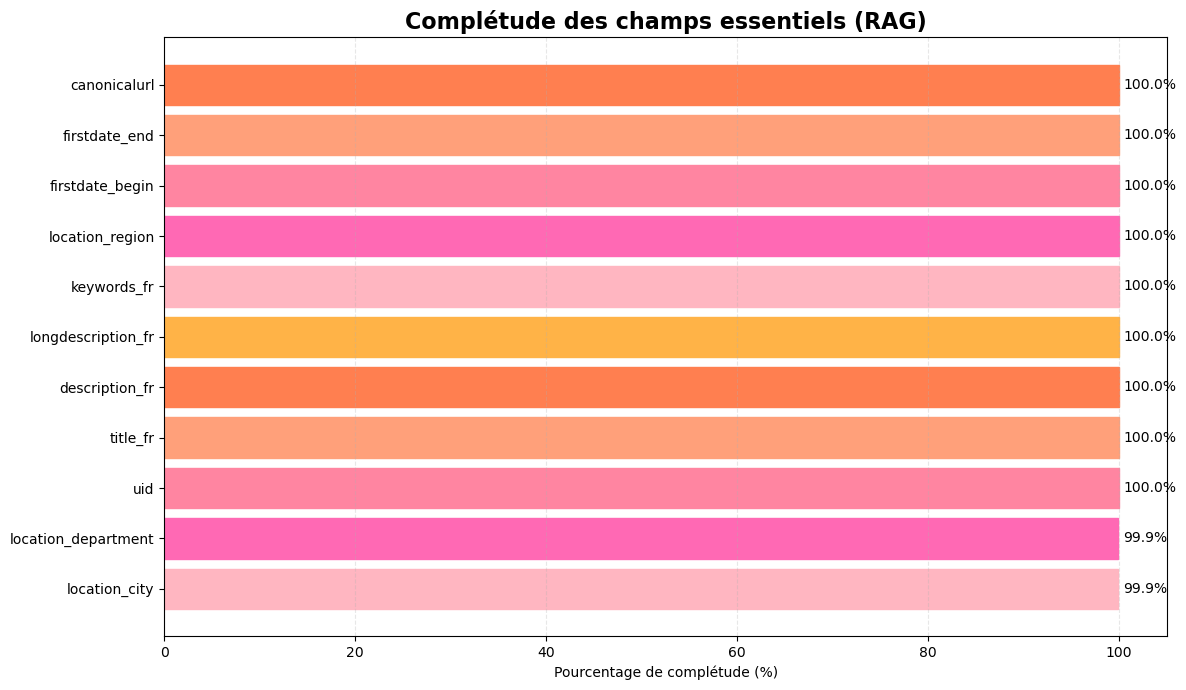

In [64]:
# Calcul complétude (% valeurs non nulles)
completeness = (1 - df.isnull().sum() / len(df)) * 100

# On garde uniquement les champs essentiels
completeness = completeness[rag_columns].sort_values(ascending=True)

# Figure
plt.figure(figsize=(12, 7))

bars = plt.barh(
    completeness.index,
    completeness.values
)

# 🎨 Couleurs rose / orange
colors = ["#FFB6C1", "#FF69B4", "#FF85A1", "#FFA07A", "#FF7F50", "#FFB347"]

for i, bar in enumerate(bars):
    bar.set_color(colors[i % len(colors)])

    # affichage des valeurs
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}%",
        va="center",
        fontsize=10
    )

# 🧁 Style joli
plt.title("Complétude des champs essentiels (RAG)", fontsize=16, fontweight="bold")
plt.xlabel("Pourcentage de complétude (%)")
plt.xlim(0, 105)
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Statistique textueles 

In [67]:
print("=" * 75)
print("STATISTIQUES SUR LES CHAMPS TEXTUELS - NOMBRES DE CARACTÈRES")
print("=" * 75)

# Calcul des longueurs
df["title_length"] = df["title_fr"].fillna("").astype(str).str.len()

df["description_length"] = (
    df["description_fr"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["longdescription_length"] = (
    df["longdescription_fr"]
    .fillna("")
    .astype(str)
    .str.len()
)

# Tableau récapitulatif
stats_df = pd.DataFrame({
    "Titres": df["title_length"].describe(),
    "Descriptions courtes": df["description_length"].describe(),
    "Descriptions longues": df["longdescription_length"].describe()
}).round(2)

display(stats_df)

STATISTIQUES SUR LES CHAMPS TEXTUELS - NOMBRES DE CARACTÈRES


,Titres,Descriptions courtes,Descriptions longues
count,8305.00,8305.00,8305.00
mean,64.10,171.35,540.95
std,30.14,43.71,261.86
min,7.00,12.00,22.00
25%,40.00,149.00,429.00
50%,61.00,199.00,507.00
75%,85.00,200.00,513.00
max,149.00,200.00,1961.00


In [69]:
df["total_text_length"] = (
    df["title_fr"].fillna("").astype(str).str.len()
    + df["description_fr"].fillna("").astype(str).str.len()
    + df["longdescription_fr"].fillna("").astype(str).str.len()
)

print("\n--- Texte total par événement ---")
print(df["total_text_length"].describe())


--- Texte total par événement ---
count    8305.000000
mean      776.399639
std       287.027729
min        57.000000
25%       643.000000
50%       744.000000
75%       812.000000
max      2214.000000
Name: total_text_length, dtype: float64


In [70]:
print("=" * 75)
print("ÉVÉNEMENTS AVEC DESCRIPTIONS PROBLÉMATIQUES")
print("=" * 75)

problematic = df[
    (df["description_fr"].isna()) |
    (df["description_fr"].fillna("").str.len() < 20)
]

print(f"Nombre d'événements concernés : {len(problematic)}")

display(
    problematic[
        ["uid", "title_fr", "description_fr"]
    ].head(20)
)

ÉVÉNEMENTS AVEC DESCRIPTIONS PROBLÉMATIQUES
Nombre d'événements concernés : 11


,uid,title_fr,description_fr
36,68625398,L'emploi fait sa rentrée,Forum emploi
382,34108567,L'emploi fait sa rentrée,Forum emploi
1855,79671504,L'emploi fait sa rentrée,Forum emploi
3252,11208307,FORUM RECRUTEMENT FORMATION BTP (CRENEAU 09H30...,Le BTP vous tente?
4041,75966827,L'emploi fait sa rentrée,Forum emploi
4704,75783038,"Réunion d'information : FORMATION "" Visant u...",FORMATION ANNULEE
5049,67189949,Forum Horizon Emploi,C'EST OFFICIEL !
5317,5927089,FORUM RECRUTEMENT FORMATION BTP (CRENEAU 10H30...,Le BTP vous tente?
5724,511968,MATINS FUTES - L'ALTERNANCE SANS DETOUR - CLPS,Une question ?
6141,88189301,MATINS FUTES - L'ALTERNANCE SANS DETOUR - Facu...,Une question ?


In [73]:
print("=" * 75)
print("EXEMPLES DE DESCRIPTIONS TRÈS COURTES")
print("=" * 75)

short_desc = (
    df.assign(
        description_length=df["description_fr"]
        .fillna("")
        .astype(str)
        .str.len()
    )
    .sort_values("description_length")
)

display(
    short_desc[
        ["title_fr", "description_fr", "description_length"]
    ].head(10)
)

EXEMPLES DE DESCRIPTIONS TRÈS COURTES


,title_fr,description_fr,description_length
1855,L'emploi fait sa rentrée,Forum emploi,12
382,L'emploi fait sa rentrée,Forum emploi,12
36,L'emploi fait sa rentrée,Forum emploi,12
4041,L'emploi fait sa rentrée,Forum emploi,12
5724,MATINS FUTES - L'ALTERNANCE SANS DETOUR - CLPS,Une question ?,14
6141,MATINS FUTES - L'ALTERNANCE SANS DETOUR - Facu...,Une question ?,14
8247,PORTES OUVERTES CFAI,PORTES OUVERTES,15
5049,Forum Horizon Emploi,C'EST OFFICIEL !,16
4704,"Réunion d'information : FORMATION "" Visant u...",FORMATION ANNULEE,17
5317,FORUM RECRUTEMENT FORMATION BTP (CRENEAU 10H30...,Le BTP vous tente?,18


### Analyse de lians

In [76]:
import re

html_pattern = re.compile(r"<[^>]+>")

df["contains_html"] = df["longdescription_fr"].fillna("").str.contains(
    html_pattern,
    regex=True
)

print("=" * 75)
print("ÉVÉNEMENTS CONTENANT DU HTML")
print("=" * 75)

print(f"Nombre d'événements : {len(df):,}")
print(f"Contenant du HTML : {df['contains_html'].sum():,}")
print(f"Pourcentage : {df['contains_html'].mean()*100:.2f}%")

ÉVÉNEMENTS CONTENANT DU HTML
Nombre d'événements : 8,305
Contenant du HTML : 8,305
Pourcentage : 100.00%


In [78]:
from bs4 import BeautifulSoup
from collections import Counter

tag_counter = Counter()

for html in df["longdescription_fr"].dropna():
    soup = BeautifulSoup(str(html), "html.parser")

    for tag in soup.find_all():
        tag_counter[tag.name] += 1

print("=" * 75)
print("FRÉQUENCE DES BALISES HTML")
print("=" * 75)

for tag, count in tag_counter.most_common(20):
    print(f"{tag:<10} {count:,}")

FRÉQUENCE DES BALISES HTML
p          12,855
li         342
ul         274
ol         50
strong     37
em         36
br         16
a          13


In [80]:
from bs4 import BeautifulSoup

tags_to_check = ["title", "h1", "h2", "h3", "h4", "h5", "h6",
                 "p", "ol", "ul", "li", "a"]

results = []

for tag in tags_to_check:

    count = 0

    for html in df["longdescription_fr"].dropna():

        soup = BeautifulSoup(str(html), "html.parser")

        if soup.find(tag):
            count += 1

    results.append({
        "Balise": tag,
        "Nb événements": count,
        "%": round(count / len(df) * 100, 2)
    })

display(pd.DataFrame(results))

,Balise,Nb événements,%
0,title,0,0.00
1,h1,0,0.00
2,h2,0,0.00
3,h3,0,0.00
4,h4,0,0.00
5,h5,0,0.00
6,h6,0,0.00
7,p,8301,99.95
8,ol,50,0.60
9,ul,273,3.29


In [82]:
from bs4 import BeautifulSoup

html = df["longdescription_fr"].dropna().iloc[0]

soup = BeautifulSoup(html, "html.parser")

print("=" * 75)
print("HTML BRUT")
print("=" * 75)

print(html[:2000])

print("\n")
print("=" * 75)
print("TEXTE NETTOYÉ")
print("=" * 75)

print(soup.get_text(separator="\n"))

HTML BRUT
<p>Il vous sera présenté la formation chargé-e d’accueil tourisme et loisirs .De plus, un employeur interviendra pour vous expliquer les compétences et les conditions de travail .Des entretiens seront possibles avec la formatrice pour la prochaine session de septembre en fin de matinée</p>
<p>Il vous sera présenté la formation chargé-e d’accueil tourisme et loisirs .De plus, un employeur interviendra pour vous expliquer les compétences et les conditions de travail .Des entretiens seront possibles avec la formatrice pour la prochaine session de septembre en fin de matinéePour information: la formation ouvre à des postes en accueil, gestion administrative, commerciale, réseaux sociaux, organisation d'évènement, accompagnement sur activité de loisirs, réception en hôtellerie etc...</p>


TEXTE NETTOYÉ
Il vous sera présenté la formation chargé-e d’accueil tourisme et loisirs .De plus, un employeur interviendra pour vous expliquer les compétences et les conditions de travail .Des 

In [84]:
from bs4 import BeautifulSoup

stats = {
    "TITLE": 0,
    "H1": 0,
    "H2": 0,
    "H3": 0,
    "H4": 0,
    "H5": 0,
    "H6": 0,
    "P": 0,
    "UL": 0,
    "OL": 0,
    "LI": 0,
    "A": 0
}

for html in df["longdescription_fr"].dropna():

    soup = BeautifulSoup(str(html), "html.parser")

    for tag in stats.keys():
        stats[tag] += len(soup.find_all(tag.lower()))

print("=" * 75)
print("STRUCTURE HTML DU DATASET")
print("=" * 75)

for tag, count in stats.items():
    print(f"{tag:<10} {count:,}")

STRUCTURE HTML DU DATASET
TITLE      0
H1         0
H2         0
H3         0
H4         0
H5         0
H6         0
P          12,855
UL         274
OL         50
LI         342
A          13


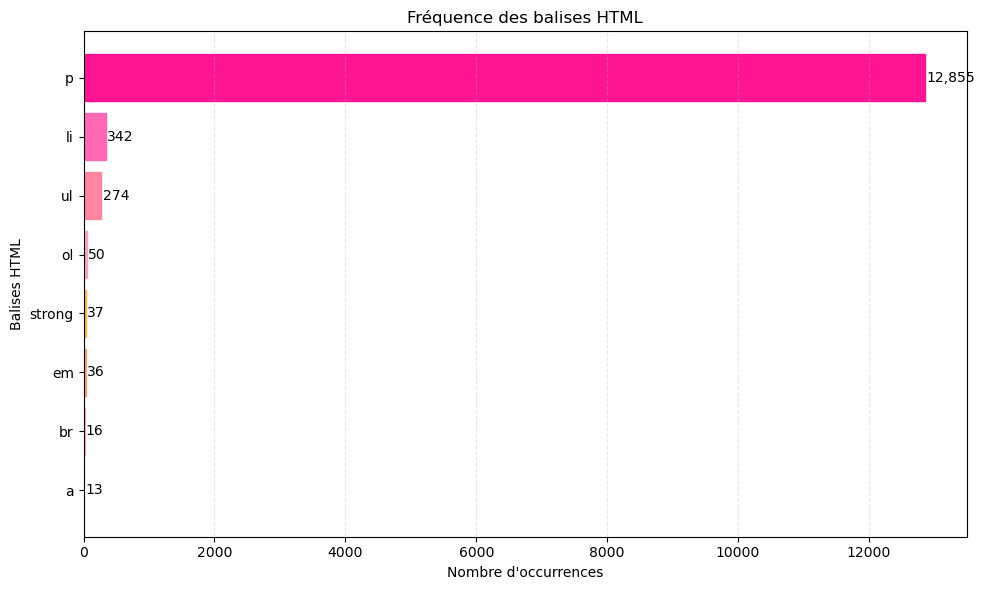

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

tags_df = pd.DataFrame({
    "Balise": ["p", "li", "ul", "ol", "strong", "em", "br", "a"],
    "Occurrences": [12855, 342, 274, 50, 37, 36, 16, 13]
})

tags_df = tags_df.sort_values("Occurrences")

plt.figure(figsize=(10,6))

bars = plt.barh(
    tags_df["Balise"],
    tags_df["Occurrences"]
)

colors = [
    "#FFD1DC",
    "#FFB6C1",
    "#FFA07A",
    "#FFB347",
    "#F4A6C1",
    "#FF85A1",
    "#FF69B4",
    "#FF1493"
]

for i, bar in enumerate(bars):
    bar.set_color(colors[i % len(colors)])

# Valeurs au bout des barres
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center"
    )

plt.title("Fréquence des balises HTML")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Balises HTML")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Distribution des evenement departement vs villes 

In [89]:
print("=" * 75)
print("RÉPARTITION DES ÉVÉNEMENTS PAR DÉPARTEMENT (TOP 50)")
print("=" * 75)

dept_counts = (
    df["location_department"]
    .value_counts()
    .head(50)
)

display(
    dept_counts.to_frame(
        name="Nombre d'événements"
    )
)

RÉPARTITION DES ÉVÉNEMENTS PAR DÉPARTEMENT (TOP 50)


,Nombre d'événements
location_department,
Nord,556
Bouches-du-Rhône,272
Gironde,265
Pas-de-Calais,245
Aisne,208
Val-d'Oise,202
Métropole de Lyon,199
Seine-Saint-Denis,177
Ille-et-Vilaine,175


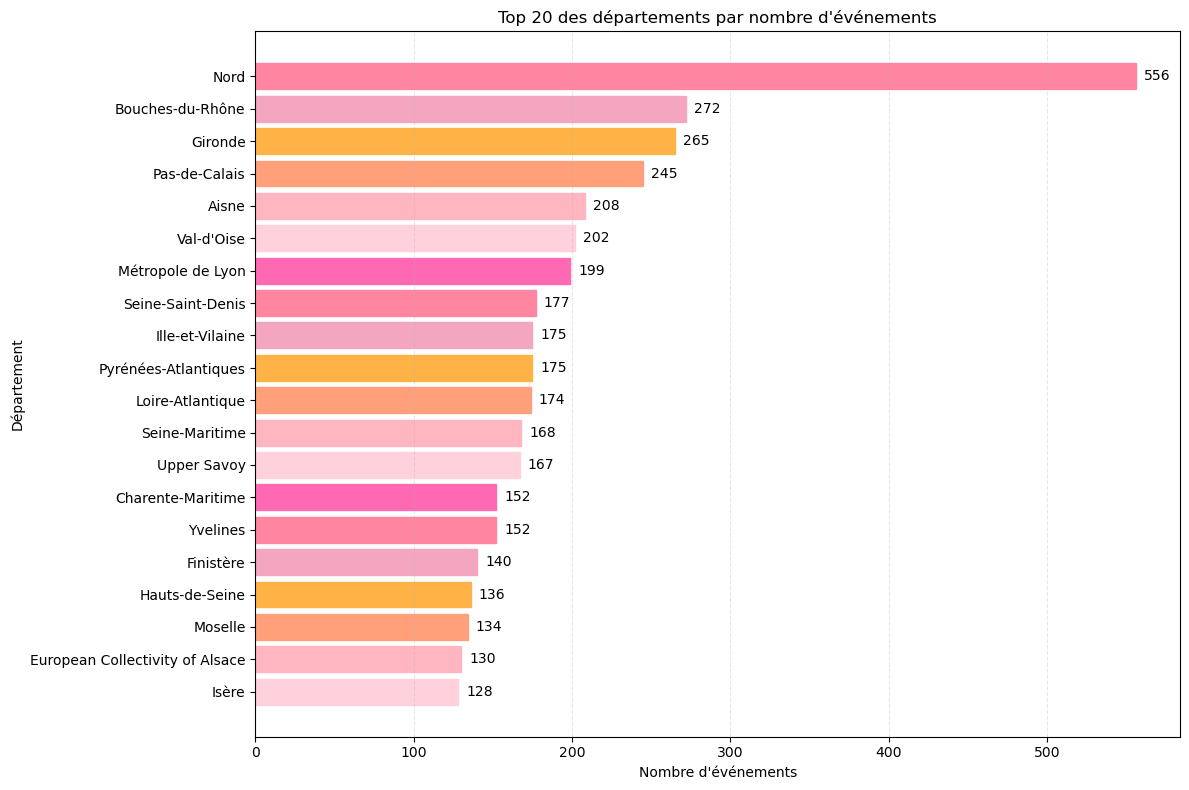

In [91]:
import matplotlib.pyplot as plt

top_departements = (
    df["location_department"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_departements.index,
    top_departements.values
)

# Palette rose/orange
colors = [
    "#FFD1DC",
    "#FFB6C1",
    "#FFA07A",
    "#FFB347",
    "#F4A6C1",
    "#FF85A1",
    "#FF69B4"
]

for i, bar in enumerate(bars):
    bar.set_color(colors[i % len(colors)])

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.title("Top 20 des départements par nombre d'événements")
plt.xlabel("Nombre d'événements")
plt.ylabel("Département")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
print("=" * 75)
print("RÉPARTITION DES ÉVÉNEMENTS PAR VILLE (TOP 50)")
print("=" * 75)

city_counts = (
    df["location_city"]
    .value_counts()
    .head(50)
)

display(
    city_counts.to_frame(
        name="Nombre d'événements"
    )
)

RÉPARTITION DES ÉVÉNEMENTS PAR VILLE (TOP 50)


,Nombre d'événements
location_city,
Marseille,156
Paris,110
Lyon,85
Laon,82
Rennes,76
La Rochelle,67
Lille,67
Dole,61
Limoges,58


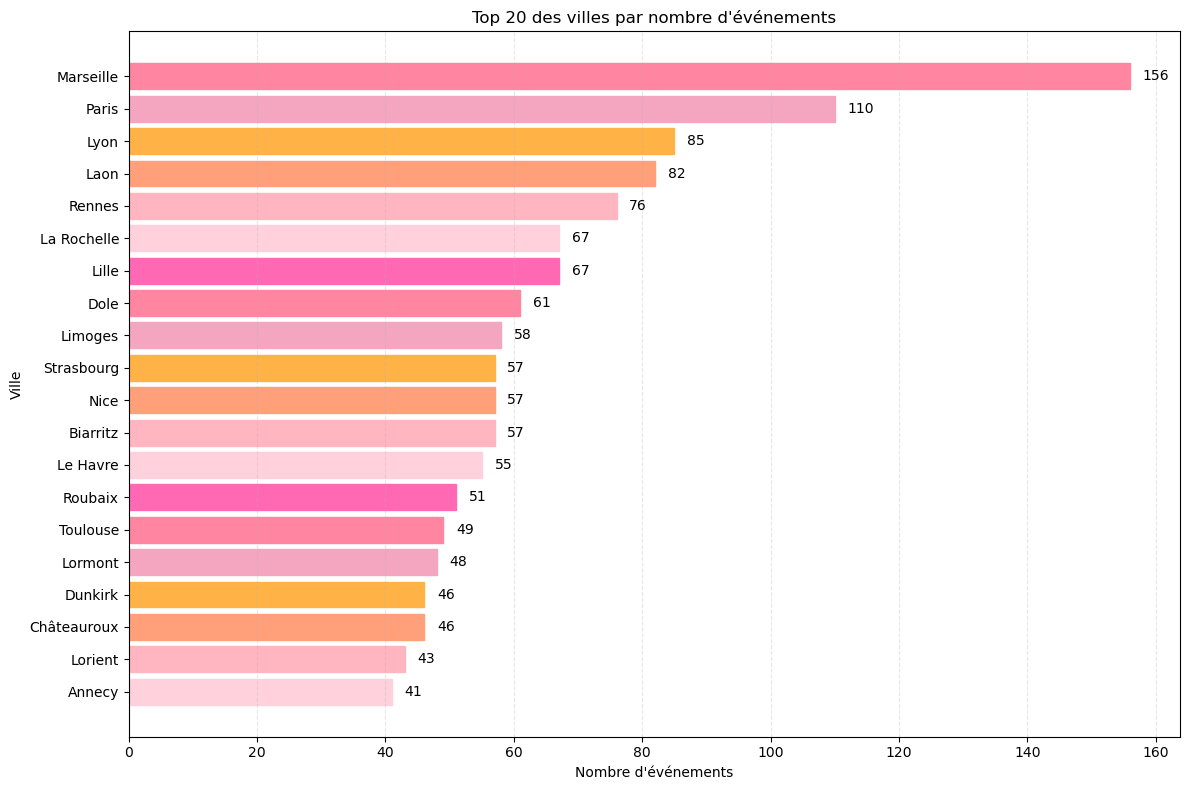

In [95]:
import matplotlib.pyplot as plt

top_cities = (
    df["location_city"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_cities.index,
    top_cities.values
)

# Palette rose/orange 🌸
colors = [
    "#FFD1DC",
    "#FFB6C1",
    "#FFA07A",
    "#FFB347",
    "#F4A6C1",
    "#FF85A1",
    "#FF69B4"
]

for i, bar in enumerate(bars):
    bar.set_color(colors[i % len(colors)])

# Affichage des valeurs
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.title("Top 20 des villes par nombre d'événements")
plt.xlabel("Nombre d'événements")
plt.ylabel("Ville")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Distribution par mois VS jours de la semaine

In [98]:
print("=" * 75)
print("FORMAT DES DATES")
print("=" * 75)

for date in df["firstdate_begin"].head(5):
    print(date)

FORMAT DES DATES
2025-03-18T09:00:00+01:00
2025-03-27T09:00:00+01:00
2025-09-04T11:00:00+02:00
2025-09-04T14:00:00+02:00
2025-09-04T14:30:00+02:00


In [100]:
print("=" * 75)
print("DISTRIBUTION DES ÉVÉNEMENTS PAR MOIS")
print("=" * 75)

# Conversion en datetime
df["firstdate_begin"] = pd.to_datetime(
    df["firstdate_begin"],
    utc=True
)

# Comptage des événements par mois
month_counts = (
    df["firstdate_begin"]
    .dt.strftime("%Y-%m")
    .value_counts()
)

# Création de tous les mois entre la date min et max du dataset
all_months = pd.date_range(
    start=df["firstdate_begin"].min().strftime("%Y-%m-01"),
    end=df["firstdate_begin"].max().strftime("%Y-%m-01"),
    freq="MS"
).strftime("%Y-%m")

# Réindexation pour inclure les mois manquants
month_counts = month_counts.reindex(
    all_months,
    fill_value=0
)

display(
    month_counts.to_frame(
        name="Nombre d'événements"
    )
)

DISTRIBUTION DES ÉVÉNEMENTS PAR MOIS


,Nombre d'événements
2025-02,27
2025-03,314
2025-04,6
2025-05,0
2025-06,0
2025-07,0
2025-08,540
2025-09,3333
2025-10,1460
2025-11,1618


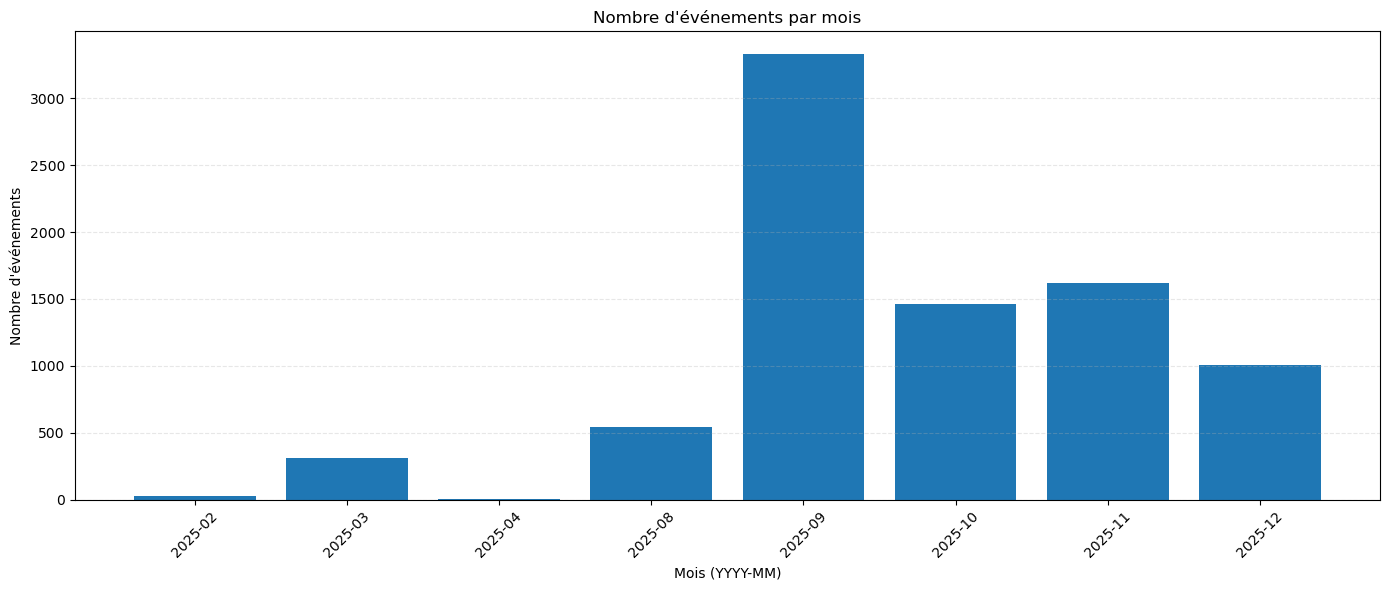

In [102]:
month_counts = (
    df["firstdate_begin"]
    .dt.strftime("%Y-%m")
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,6))

bars = plt.bar(
    month_counts.index,
    month_counts.values
)

plt.title("Nombre d'événements par mois")
plt.xlabel("Mois (YYYY-MM)")
plt.ylabel("Nombre d'événements")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [104]:
print("=" * 75)
print("DISTRIBUTION DES ÉVÉNEMENTS PAR JOUR DE LA SEMAINE")
print("=" * 75)

# Conversion en datetime
df["firstdate_begin"] = pd.to_datetime(
    df["firstdate_begin"],
    utc=True
)

# Dictionnaire français
jours_fr = {
    0: "Lundi",
    1: "Mardi",
    2: "Mercredi",
    3: "Jeudi",
    4: "Vendredi",
    5: "Samedi",
    6: "Dimanche"
}

# Extraction du jour
df["jour_semaine"] = (
    df["firstdate_begin"]
    .dt.dayofweek
    .map(jours_fr)
)

# Ordre correct
ordre_jours = [
    "Lundi",
    "Mardi",
    "Mercredi",
    "Jeudi",
    "Vendredi",
    "Samedi",
    "Dimanche"
]

# Comptage
jour_counts = (
    df["jour_semaine"]
    .value_counts()
    .reindex(ordre_jours, fill_value=0)
)

display(
    jour_counts.to_frame(
        name="Nombre d'événements"
    )
)

DISTRIBUTION DES ÉVÉNEMENTS PAR JOUR DE LA SEMAINE


,Nombre d'événements
jour_semaine,
Lundi,1115
Mardi,2690
Mercredi,1464
Jeudi,2057
Vendredi,950
Samedi,24
Dimanche,5


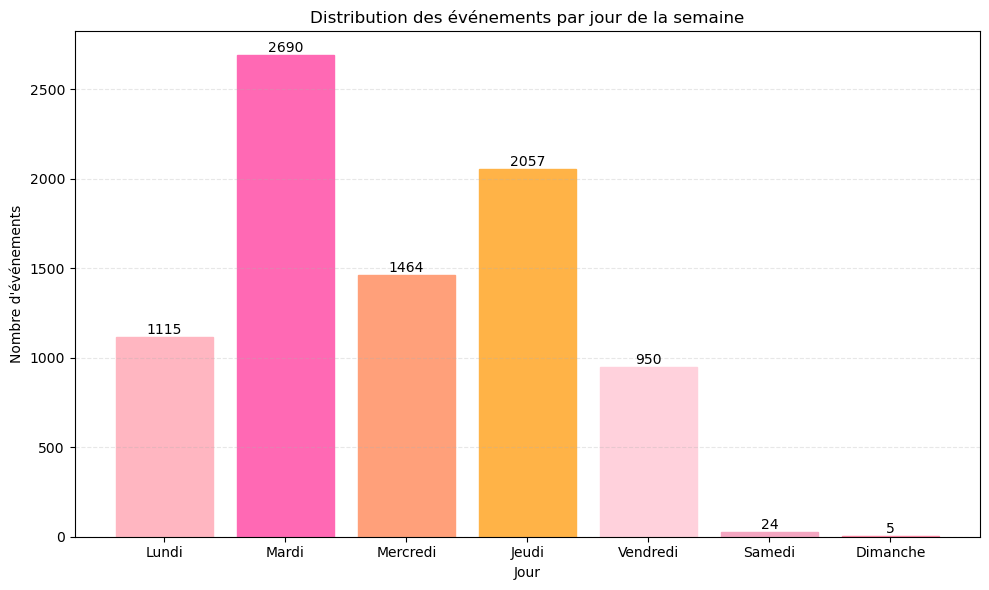

In [106]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    jour_counts.index,
    jour_counts.values
)

colors = [
    "#FFB6C1",
    "#FF69B4",
    "#FFA07A",
    "#FFB347",
    "#FFD1DC",
    "#F4A6C1",
    "#FF85A1"
]

for i, bar in enumerate(bars):
    bar.set_color(colors[i])

# Affichage des valeurs
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.title("Distribution des événements par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Nombre d'événements")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Keywords 

In [109]:
print("=" * 75)
print("STATISTIQUES SUR LES MOTS-CLÉS")
print("=" * 75)

all_keywords = []

for keywords in df["keywords_fr"]:
    if isinstance(keywords, list):
        all_keywords.extend(keywords)

keyword_counts = Counter(all_keywords)

print(f"Nombre total de mots-clés : {len(keywords):,}")
print(f"Nombre de mots-clés uniques : {len(set(all_keywords)):,}")

STATISTIQUES SUR LES MOTS-CLÉS
Nombre total de mots-clés : 1
Nombre de mots-clés uniques : 135


In [111]:
print("=" * 75)
print("NOMBRE DE MOTS-CLÉS PAR ÉVÉNEMENT")
print("=" * 75)

df["nb_keywords"] = df["keywords_fr"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

display(
    df["nb_keywords"].describe().to_frame(
        name="Valeur"
    )
)

NOMBRE DE MOTS-CLÉS PAR ÉVÉNEMENT


,Valeur
count,8305.000000
mean,7.014449
std,4.779637
min,1.000000
25%,4.000000
50%,6.000000
75%,9.000000
max,40.000000


In [113]:
from collections import Counter

print("=" * 75)
print("TOP 50 DES MOTS-CLÉS")
print("=" * 75)

all_keywords = []

for keywords in df["keywords_fr"]:
    if isinstance(keywords, list):
        all_keywords.extend(keywords)

keyword_counts = Counter(all_keywords)

keywords_df = pd.DataFrame(
    keyword_counts.items(),
    columns=["Mot-clé", "Occurrences"]
).sort_values(
    "Occurrences",
    ascending=False
)

display(
    keywords_df.head(50)
)

TOP 50 DES MOTS-CLÉS


,Mot-clé,Occurrences
8,Découverte formation,8305
7,Découverte secteur / métier,4876
2,1 jeune 1 solution,4339
9,S'informer,4222
1,#TousMobilisés,3323
16,Recrutement,2820
14,en physique,2575
11,Tout public,2232
10,Marché du travail,2193
0,Réunion d'information,1562


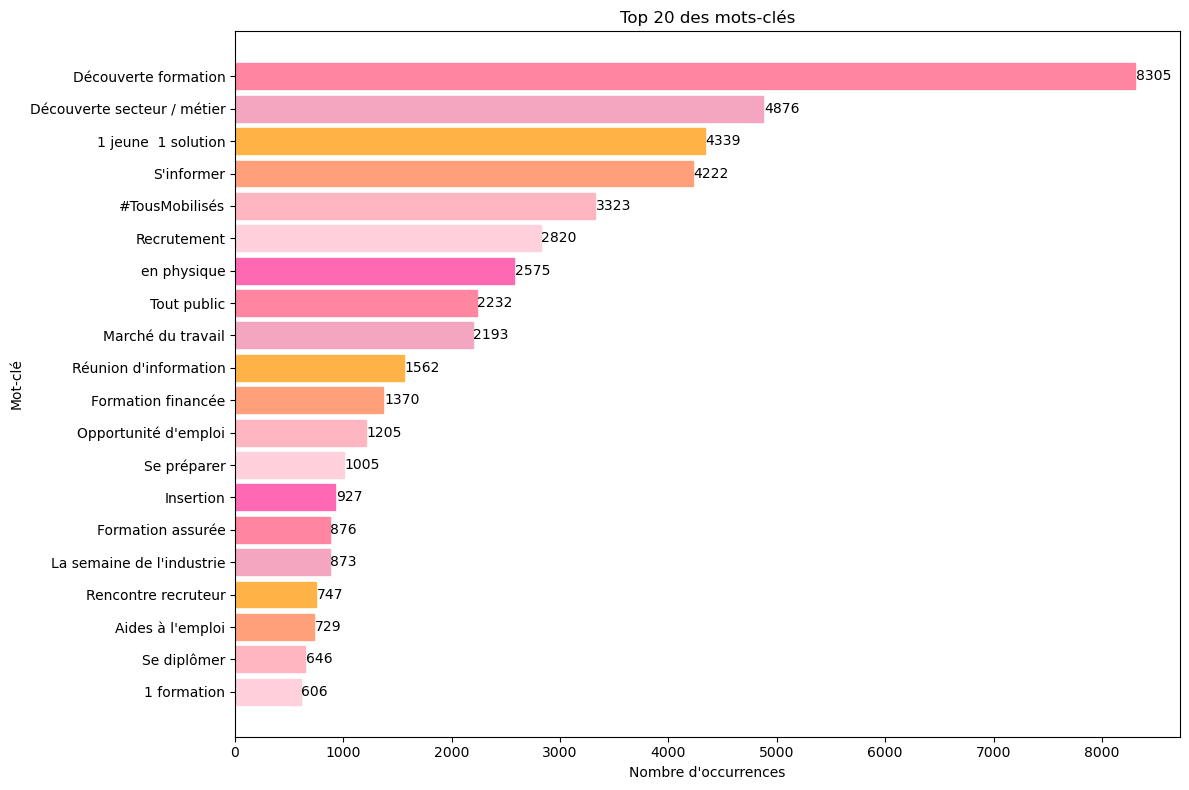

In [115]:
top_keywords = keywords_df.head(20).sort_values("Occurrences")

plt.figure(figsize=(12,8))

bars = plt.barh(
    top_keywords["Mot-clé"],
    top_keywords["Occurrences"]
)

colors = [
    "#FFD1DC",
    "#FFB6C1",
    "#FFA07A",
    "#FFB347",
    "#F4A6C1",
    "#FF85A1",
    "#FF69B4"
]

for i, bar in enumerate(bars):
    bar.set_color(colors[i % len(colors)])

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.title("Top 20 des mots-clés")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Mot-clé")

plt.tight_layout()
plt.show()

## Analyse JSON 

In [118]:
import json

print("=" * 75)
print("TEST DES CHAMPS JSON")
print("=" * 75)

json_columns = []

for col in df.columns:
    sample = df[col].dropna().astype(str).head(1)

    if len(sample) > 0:
        value = sample.iloc[0]

        if value.startswith("{") or value.startswith("["):
            json_columns.append(col)

print("Colonnes JSON détectées :")
print(json_columns)

TEST DES CHAMPS JSON
Colonnes JSON détectées :
['keywords_fr', 'timings', 'location_coordinates', 'attendancemode', 'status', 'registration', 'links']


In [120]:
import json

df["attendancemode_parsed"] = df["attendancemode"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else x
)

In [122]:
print(df["attendancemode_parsed"].iloc[0])

{'id': 1, 'label': {'fr': 'Sur place', 'en': 'In situ', 'it': 'In presenza', 'es': 'Desconnectad', 'de': 'Offline', 'br': 'War al lec’h', 'io': 'crwdns14266:0crwdne14266:0', 'oc': 'Sus plaça'}}


In [124]:
def get_attendance_label_fr(x):
    try:
        if isinstance(x, str):
            x = json.loads(x)
        return x.get("label", {}).get("fr")
    except Exception:
        return None

df["attendancemode_label"] = df["attendancemode"].apply(
    get_attendance_label_fr
)

In [126]:
df["attendancemode_label"].value_counts()

attendancemode_label
Sur place    8240
En ligne       61
Mixte           4
Name: count, dtype: int64

In [128]:
print(df.columns.tolist())

['uid', 'slug', 'canonicalurl', 'title_fr', 'description_fr', 'longdescription_fr', 'conditions_fr', 'keywords_fr', 'image', 'imagecredits', 'thumbnail', 'originalimage', 'updatedat', 'daterange_fr', 'firstdate_begin', 'firstdate_end', 'lastdate_begin', 'lastdate_end', 'timings', 'accessibility', 'accessibility_label_fr', 'location_uid', 'location_coordinates', 'location_name', 'location_address', 'location_district', 'location_insee', 'location_postalcode', 'location_city', 'location_department', 'location_region', 'location_countrycode', 'location_image', 'location_imagecredits', 'location_phone', 'location_website', 'location_links', 'location_tags', 'location_description_fr', 'location_access_fr', 'attendancemode', 'onlineaccesslink', 'status', 'age_min', 'age_max', 'originagenda_title', 'originagenda_uid', 'contributor_email', 'contributor_contactnumber', 'contributor_contactname', 'contributor_contactposition', 'contributor_organization', 'category', 'country_fr', 'registration',

In [130]:
print(df["contains_html"].dtype)
print(df["contains_html"].value_counts())

bool
contains_html
True    8305
Name: count, dtype: int64


## Preparation de donnees 

In [133]:
print("=" * 75)
print("RECOMMANDATIONS DE NETTOYAGE POUR RAG")
print("=" * 75)

print("""
1. SUPPRESSION HTML (OBLIGATOIRE)
   - Nettoyer longdescription_fr
   - Supprimer <p>, <br>, <li>, etc.
   => améliore qualité embeddings

2. PARSING JSON (IMPORTANT)
   - attendancemode → mode lisible (Sur place / En ligne)
   - links → extraction URL si utile
   - timings → dates structurées

3. FILTRAGE DONNÉES (CRUCIAL)
   - supprimer lignes sans title_fr
   - supprimer lignes sans description_fr
   => élimine bruit et faux documents

4. CRÉATION DU TEXTE RAG (OBLIGATOIRE)
   - text_for_embedding =
     title + description + keywords + location + mode + date

=> C'est LE cœur du système RAG
""")

RECOMMANDATIONS DE NETTOYAGE POUR RAG

1. SUPPRESSION HTML (OBLIGATOIRE)
   - Nettoyer longdescription_fr
   - Supprimer <p>, <br>, <li>, etc.
   => améliore qualité embeddings

2. PARSING JSON (IMPORTANT)
   - attendancemode → mode lisible (Sur place / En ligne)
   - links → extraction URL si utile
   - timings → dates structurées

3. FILTRAGE DONNÉES (CRUCIAL)
   - supprimer lignes sans title_fr
   - supprimer lignes sans description_fr
   => élimine bruit et faux documents

4. CRÉATION DU TEXTE RAG (OBLIGATOIRE)
   - text_for_embedding =
     title + description + keywords + location + mode + date

=> C'est LE cœur du système RAG



In [135]:
import json
from pathlib import Path

def convert(obj):
    if hasattr(obj, "item"):
        return obj.item()
    return obj

stats_summary = {
    "Métrique": [
        "Total événements",
        "Avec titre",
        "Sans titre",
        "Avec description",
        "Sans description",
        "Avec mots-clés",
        "Avec HTML",
        "Départements",
        "Villes"
    ],
    "Valeur": [
        convert(len(df)),
        convert(df["title_fr"].notna().sum()),
        convert(df["title_fr"].isna().sum()),
        convert(df["description_fr"].notna().sum()),
        convert(df["description_fr"].isna().sum()),
        convert(df["keywords_fr"].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()),
        convert(df["contains_html"].sum()),
        convert(df["location_department"].nunique()),
        convert(df["location_city"].nunique())
    ]
}

# 👉 CHEMIN WINDOWS (IMPORTANT)
stats_path = Path(r"C:\Users\amela\P9 RAG\exploration_stats.json")

with open(stats_path, "w", encoding="utf-8") as f:
    json.dump(stats_summary, f, ensure_ascii=False, indent=2)

print("✅ Fichier sauvegardé ici :")
print(stats_path)

✅ Fichier sauvegardé ici :
C:\Users\amela\P9 RAG\exploration_stats.json


### CHUNKING

In [184]:
def simple_chunk(text, max_words=80):
    words = str(text).split()
    return [" ".join(words[i:i+max_words]) for i in range(0, len(words), max_words)]

### VECTORISATION (embeddings)

In [191]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

print("✅ Modèle chargé")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Modèle chargé


In [193]:
emb = model.encode("Bonjour tout le monde")

print(type(emb))
print(emb.shape)

<class 'numpy.ndarray'>
(384,)


In [197]:
embeddings = model.encode(df["title_fr"].fillna("").tolist())
print(embeddings.shape)

(8305, 384)


In [137]:
def format_keywords(x):
    if isinstance(x, list):
        return " ".join(x)
    return str(x) if pd.notna(x) else ""

df["rag_text"] = (
    "Titre : " + df["title_fr"].fillna("") +
    "\nDescription : " + df["description_fr"].fillna("") +
    "\nMots-clés : " + df["keywords_fr"].apply(format_keywords) +
    "\nVille : " + df["location_city"].fillna("") +
    "\nDépartement : " + df["location_department"].fillna("") +
    "\nRégion : " + df["location_region"].fillna("") +
    "\nDate début : " + df["firstdate_begin"].astype(str)
)

In [139]:
print(df["rag_text"].iloc[0])

Titre : PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL TOURISME ET LOISIRS A LA MFR DES SABLES D'OLONNE
Description : Il vous sera présenté la formation chargé-e d’accueil tourisme et loisirs .De plus, un employeur interviendra pour vous expliquer les compétences et les conditions de travail .Des entretiens seron...
Mots-clés : Réunion d'information #TousMobilisés 1 jeune  1 solution La semaine du Tourisme Hôtellerie-Restauration Tourisme Loisirs et Animation Découverte secteur / métier Découverte formation S'informer Marché du travail Tout public Formation assurée Se diplômer en physique
Ville : Les Sables-d'Olonne
Département : Vendée
Région : Pays de la Loire
Date début : 2025-03-18 08:00:00+00:00


### découpage les textes en chunks

In [143]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

print("OK")

OK


In [145]:
import pandas as pd

chunks = []
metadata = []

for _, row in df.iterrows():

    # -------------------------
    # SAFE VALUES
    # -------------------------
    title = str(row.get("title_fr", "") or "")
    description = str(row.get("description_fr", "") or "")

    # -------------------------
    # KEYWORDS SAFE
    # -------------------------
    keywords = row.get("keywords_fr", [])

    if keywords is None:
        keywords = []

    elif not isinstance(keywords, list):
        keywords = [str(keywords)]

    keywords_text = ", ".join(keywords)

    # -------------------------
    # AUTRES CHAMPS
    # -------------------------
    city = str(row.get("location_city", "") or "")
    region = str(row.get("location_region", "") or "")
    department = str(row.get("location_department", "") or "")
    mode = str(row.get("attendancemode_label", "") or "")
    url = str(row.get("canonicalurl", "") or "")

    # -------------------------
    # DATE SAFE
    # -------------------------
    date_raw = row.get("firstdate_begin", None)

    date = pd.to_datetime(date_raw, errors="coerce")
    if pd.isna(date):
        date = None

    # -------------------------
    # RAG TEXT (IMPORTANT)
    # -------------------------
    text = f"""
FORMATION: {title}

DESCRIPTION: {description}

COMPETENCES: {keywords_text}

LOCALISATION: {city} - {department} - {region}

MODE: {mode}

DATE: {date}

URL: {url}
""".strip()

    # -------------------------
    # SPLITTING 
    # -------------------------
    split_texts = splitter.split_text(text)

    for chunk in split_texts:

        chunks.append(chunk)

        metadata.append({
            "uid": row.get("uid", ""),
            "title": title,
            "city": city,
            "department": department,
            "region": region,
            "keywords": keywords,
            "date": date,
            "mode": mode,
            "url": url
        })

# -------------------------
# CHECK FINAL
# -------------------------
print("Nombre de chunks :", len(chunks))
print("Nombre de metadata :", len(metadata))
print("Exemple metadata :", metadata[0])

Nombre de chunks : 16511
Nombre de metadata : 16511
Exemple metadata : {'uid': '8231710', 'title': "PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL TOURISME ET LOISIRS A LA MFR DES SABLES D'OLONNE", 'city': "Les Sables-d'Olonne", 'department': 'Vendée', 'region': 'Pays de la Loire', 'keywords': ["Réunion d'information", '#TousMobilisés', '1 jeune  1 solution', 'La semaine du Tourisme', 'Hôtellerie-Restauration', 'Tourisme', 'Loisirs et Animation', 'Découverte secteur / métier', 'Découverte formation', "S'informer", 'Marché du travail', 'Tout public', 'Formation assurée', 'Se diplômer', 'en physique'], 'date': Timestamp('2025-03-18 08:00:00+0000', tz='UTC'), 'mode': 'Sur place', 'url': 'https://openagenda.com/semaine-des-metiers-du-tourisme/events/presentation-de-la-formation-charge-e-accueil-tourisme-et-loisirs-a-la-mfr-des-sables-dolonne'}


In [152]:
import pickle
import os

os.makedirs("data", exist_ok=True)

with open("data/chunks.pkl", "wb") as f:
    pickle.dump(chunks, f)

print("✅ chunks.pkl sauvegardé")

✅ chunks.pkl sauvegardé


In [153]:
with open("data/metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

print("✅ metadata.pkl sauvegardé")

✅ metadata.pkl sauvegardé


In [156]:
sum(
    "Technicien d'études du bâtiment" in c
    for c in chunks
)

1

In [158]:
sum(
    "cap électricien" in c.lower()
    for c in chunks
)

4

In [160]:
import pickle
import pandas as pd

with open("data/metadata.pkl", "rb") as f:
    metadata = pickle.load(f)

df = pd.DataFrame(metadata)

print(df.columns)
df.head()

Index(['uid', 'title', 'city', 'department', 'region', 'keywords', 'date',
       'mode', 'url'],
      dtype='object')


,uid,title,city,department,region,keywords,date,mode,url
0,8231710,PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL ...,Les Sables-d'Olonne,Vendée,Pays de la Loire,"[Réunion d'information, #TousMobilisés, 1 jeun...",2025-03-18 08:00:00+00:00,Sur place,https://openagenda.com/semaine-des-metiers-du-...
1,8231710,PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL ...,Les Sables-d'Olonne,Vendée,Pays de la Loire,"[Réunion d'information, #TousMobilisés, 1 jeun...",2025-03-18 08:00:00+00:00,Sur place,https://openagenda.com/semaine-des-metiers-du-...
2,8231710,PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL ...,Les Sables-d'Olonne,Vendée,Pays de la Loire,"[Réunion d'information, #TousMobilisés, 1 jeun...",2025-03-18 08:00:00+00:00,Sur place,https://openagenda.com/semaine-des-metiers-du-...
3,30000010,Information collective Transport,Lyon,Métropole de Lyon,Auvergne-Rhône-Alpes,"[Réunion d'information, La semaine du Tourisme...",2025-03-27 08:00:00+00:00,Sur place,https://openagenda.com/semaine-des-metiers-du-...
4,30000010,Information collective Transport,Lyon,Métropole de Lyon,Auvergne-Rhône-Alpes,"[Réunion d'information, La semaine du Tourisme...",2025-03-27 08:00:00+00:00,Sur place,https://openagenda.com/semaine-des-metiers-du-...


In [162]:
import pandas as pd

df = pd.DataFrame(metadata)

df[
    (df["city"].str.lower() == "paris")
    &
    (
        df["title"].str.contains(
            "btp|bâtiment|construction|maçon|électricien",
            case=False,
            na=False
        )
    )
][["title", "city"]]

,title,city
10882,Formation : Technicien d'études du bâtiment en...,Paris
10883,Formation : Technicien d'études du bâtiment en...,Paris
15158,formation cap électricien h/f,Paris
15159,formation cap électricien h/f,Paris


In [177]:
marseille_events = df[
    df["city"].str.contains(
        r"\bMarseille\b",
        case=False,
        na=False,
        regex=True
    )
]

print(len(marseille_events))
marseille_events.head()

324


,uid,title,city,department,region,keywords,date,mode,url
9,20754830,Préparation opérationnelle à l'emploi AUXILIA ...,Marseille,Bouches-du-Rhône,Provence-Alpes-Côte d'Azur,"[#TousMobilisés, 1 jeune 1 solution, Recrutem...",2025-09-04 12:30:00+00:00,Sur place,https://openagenda.com/francetravail/events/pr...
10,20754830,Préparation opérationnelle à l'emploi AUXILIA ...,Marseille,Bouches-du-Rhône,Provence-Alpes-Côte d'Azur,"[#TousMobilisés, 1 jeune 1 solution, Recrutem...",2025-09-04 12:30:00+00:00,Sur place,https://openagenda.com/francetravail/events/pr...
37,68209028,Information collective - Préparation Opération...,Marseille,Bouches-du-Rhône,Provence-Alpes-Côte d'Azur,"[#TousMobilisés, Découverte formation, Recrute...",2025-09-11 07:00:00+00:00,Sur place,https://openagenda.com/francetravail/events/in...
38,68209028,Information collective - Préparation Opération...,Marseille,Bouches-du-Rhône,Provence-Alpes-Côte d'Azur,"[#TousMobilisés, Découverte formation, Recrute...",2025-09-11 07:00:00+00:00,Sur place,https://openagenda.com/francetravail/events/in...
123,37241697,Réunion d'information pour VSI (valoriser son...,Marseille,Bouches-du-Rhône,Provence-Alpes-Côte d'Azur,"[1 jeune 1 solution, La semaine du BTP, #Tous...",2025-09-08 09:00:00+00:00,Sur place,https://openagenda.com/francetravail/events/re...


In [157]:
print(len(chunks))
print(chunks[0])

16511
FORMATION: PRESENTATION DE LA FORMATION CHARGE-E ACCUEIL TOURISME ET LOISIRS A LA MFR DES SABLES D'OLONNE

DESCRIPTION: Il vous sera présenté la formation chargé-e d’accueil tourisme et loisirs .De plus, un employeur interviendra pour vous expliquer les compétences et les conditions de travail .Des entretiens seron...


In [149]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

print("✅ Modèle chargé")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Modèle chargé


In [151]:
chunk_embeddings = model.encode(
    chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

embeddings = np.asarray(
    chunk_embeddings,
    dtype=np.float32
)

faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(
    embeddings.shape[1]
)

index.add(embeddings)

Batches:   0%|          | 0/516 [00:00<?, ?it/s]

In [277]:
query_embedding = model.encode([query])

In [168]:
chunk_embeddings = model.encode(
    chunks,
    show_progress_bar=False,
    normalize_embeddings=True
)
print(chunk_embeddings.shape)

(16511, 384)


In [287]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query = "formations langues etrangeres"

query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    chunk_embeddings
)[0]

indices = np.argsort(scores)[::-1]

seen_uids = set()
count = 0

for idx in indices:

    uid = metadata[idx]["uid"]

    if uid in seen_uids:
        continue

    seen_uids.add(uid)

    print("=" * 100)
    print(f"Score : {scores[idx]:.4f}")

    print("Titre :", metadata[idx]["title"])
    print("Ville :", metadata[idx]["city"])
    print("UID :", uid)

    print("\nChunk :")
    print(chunks[idx][:400])

    count += 1

    if count == 5:
        break

Score : 0.6845
Titre : FORMATION français langues étrangères métiers de l'industrie
Ville : Annecy
UID : 77437644

Chunk :
Titre : FORMATION français langues étrangères métiers de l'industrie
Description : Vous participez à l'information collective pour intégrer la formation français langues étrangères industrie qui débute le 06/10 au Greta d'Annecy 4 boulevard Taine.L'objectif : améliorer sa communicat
Mots-clés : 1 jour 1 formation 1 jeune  1 solution Le mois de la formation Découverte formation Marché du travail In
Score : 0.6315
Titre : Apprentissage de la langue française à visée professionnelle
Ville : Auboué
UID : 27615345

Chunk :
Titre : Apprentissage de la langue française à visée professionnelle
Description : Objectif de la formation :- Acquérir et/ou renforcer les compétences linguistiques en français permettant de communiquer dans les situations usuelles et/ou complexes de la vie professionnelle et quoti
Mots-clés : 1 jeune  1 solution #TousMobilisés Aides à l'emploi Inser

In [289]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query = "formations langues etrangeres"

# embedding de la requête
query_embedding = model.encode([query])

# similarité avec tous les chunks
scores = cosine_similarity(
    query_embedding,
    chunk_embeddings
)[0]

# top 5 résultats
top_k = np.argsort(scores)[::-1][:5]

for idx in top_k:

    print("=" * 100)
    print(f"Score : {scores[idx]:.4f}")

    print("Titre :", metadata[idx]["title"])
    print("Ville :", metadata[idx]["city"])
    print("UID :", metadata[idx]["uid"])

    print("URL :", metadata[idx]["url"])

    print("\nChunk trouvé :")
    print(chunks[idx][:500])

Score : 0.6845
Titre : FORMATION français langues étrangères métiers de l'industrie
Ville : Annecy
UID : 77437644
URL : https://openagenda.com/francetravail/events/formation-francais-langues-etrangeres-metiers-de-lindustrie-6770746

Chunk trouvé :
Titre : FORMATION français langues étrangères métiers de l'industrie
Description : Vous participez à l'information collective pour intégrer la formation français langues étrangères industrie qui débute le 06/10 au Greta d'Annecy 4 boulevard Taine.L'objectif : améliorer sa communicat
Mots-clés : 1 jour 1 formation 1 jeune  1 solution Le mois de la formation Découverte formation Marché du travail Insertion
Ville : Annecy
Département : Upper Savoy
Région : Auvergne-Rhône-Alpes
Score : 0.6315
Titre : Apprentissage de la langue française à visée professionnelle
Ville : Auboué
UID : 27615345
URL : https://openagenda.com/francetravail/events/apprentissage-de-la-langue-francaise-a-visee-professionnelle-156929

Chunk trouvé :
Titre : Apprentissage de 

In [291]:
for mot in ["anglais", "soudure", "soudeur", "numerique", "informatique"]:
    
    nb = sum(
        mot.lower() in chunk.lower()
        for chunk in chunks
    )

    print(mot, nb)

anglais 20
soudure 19
soudeur 40
numerique 21
informatique 68


In [293]:
query = "informatique"

for i, chunk in enumerate(chunks):

    if "informatique" in chunk.lower():

        print("="*50)
        print(metadata[i]["title"])
        print(chunk[:300])

VENEZ DECOUVRIR LES METIERS EN UNIFORME ET DE LA SECURITE
Titre : VENEZ DECOUVRIR LES METIERS EN UNIFORME ET DE LA SECURITE
Description : Au-delà des métiers de terrain, les métiers de l’uniforme et de la sécurité, ce sont aussi des emplois variés dans de très nombreux domaines (administratif, mécanique, maintenance, informatique, r...
Vous envisagez une formation ? Venez rencontrer un organisme de formation sur Bayeux !
Titre : Vous envisagez une formation ? Venez rencontrer un organisme de formation sur Bayeux !
Description : Vous souhaitez découvrir ou vous perfectionner en informatique, adresser des mails, consulter votre espace personnel France Travail ou rechercher des offres, etc. ?Ou Vous souhaitez vous perf
Vous envisagez une formation ? Venez rencontrer un organisme de formation sur Bayeux !
Titre : Vous envisagez une formation ? Venez rencontrer un organisme de formation sur Bayeux !
Description : Vous souhaitez découvrir ou vous perfectionner en informatique, adresser des m

In [295]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

queries = [
    "numerique",
    "developpeur web",
    "tourisme",
    "hotellerie",
    "restauration",
    "anglais",
    "comptabilite",
    "soudure",
]

for query in queries:

    print("\n")
    print("#" * 100)
    print(f"REQUÊTE : {query}")
    print("#" * 100)

    query_embedding = model.encode([query])

    scores = cosine_similarity(
        query_embedding,
        chunk_embeddings
    )[0]

    indices = np.argsort(scores)[::-1]

    seen_uids = set()
    count = 0

    for idx in indices:

        uid = metadata[idx]["uid"]

        if uid in seen_uids:
            continue

        seen_uids.add(uid)

        print("=" * 80)
        print(f"Score : {scores[idx]:.4f}")
        print("Titre :", metadata[idx]["title"])
        print("Ville :", metadata[idx]["city"])

        count += 1

        if count == 5:
            break



####################################################################################################
REQUÊTE : numerique
####################################################################################################
Score : 0.4831
Titre : Rencontre Recrutement Handicap
Ville : Argenteuil
Score : 0.4307
Titre : Rencontre Recrutement Handicap
Ville : Argenteuil
Score : 0.4043
Titre : Salon TAF (Travail-Avenir-Formation) de Cahors
Ville : Fontanes
Score : 0.3910
Titre : Vis ma vie au GRETA Découverte de la formation REMISE A NIVEAU
Ville : Libourne
Score : 0.3910
Titre : Vis ma vie au GRETA Découverte de la formation REMISE A NIVEAU
Ville : Libourne


####################################################################################################
REQUÊTE : developpeur web
####################################################################################################
Score : 0.6126
Titre : Titre professionnel de développeur WEB (financé par la région)
Ville : Puilboreau
Sc

batch_size = 1000
all_embeddings = []

for i in range(0, len(df), batch_size):
    print(f"Traitement : {i} / {len(df)}")

    batch = df["rag_text"].iloc[i:i+batch_size].tolist()

    emb = model.encode(batch)

    all_embeddings.append(emb)

print("Terminé !")

In [208]:
embeddings = np.vstack(all_embeddings)

print(embeddings.shape)

(8305, 384)


In [210]:
np.save("embeddings.npy", embeddings)

print("Embeddings sauvegardés")

Embeddings sauvegardés


### Faiss 

In [153]:
import faiss
import numpy as np

embeddings = np.asarray(
    chunk_embeddings,
    dtype=np.float32
)

faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(
    embeddings.shape[1]
)

index.add(embeddings)

print(index.ntotal)

16511


In [320]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

C:\Users\amela\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\amela\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [155]:
from sentence_transformers import SentenceTransformer, CrossEncoder
import numpy as np
import faiss

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("✅ Models loaded")


# -------------------------
# HELPERS
# -------------------------
def safe_text(x):
    return "" if x is None else str(x).lower()


def match_any(text, words):
    text = safe_text(text)
    return any(w in text for w in words)


# -------------------------
# RETRIEVE
# -------------------------
def retrieve(query, k=5):

    query_lower = query.lower()

    # -------------------------
    # PRE-FILTER CITY (IMPORTANT FIX)
    # -------------------------
    candidate_indices = list(range(len(metadata)))

    if "paris" in query_lower:
        candidate_indices = [
            i for i in candidate_indices
            if "paris" in metadata[i]["city"].lower()
        ]

    if "marseille" in query_lower:
        candidate_indices = [
            i for i in candidate_indices
            if "marseille" in metadata[i]["city"].lower()
        ]

    # si filtre vide → fallback global
    if len(candidate_indices) == 0:
        candidate_indices = list(range(len(metadata)))

    # -------------------------
    # EMBEDDING QUERY
    # -------------------------
    q = model.encode([query], normalize_embeddings=True).astype(np.float32)

    D, I = index.search(q, k * 50)

    candidates = []

    for rank, idx in enumerate(I[0]):

        if idx == -1:
            continue

        if idx not in candidate_indices:
            continue  # <-- IMPORTANT FIX

        meta = metadata[idx]

        candidates.append({
            "faiss_score": float(D[0][rank]),
            "title": meta["title"],
            "city": meta["city"],
            "region": meta["region"],
            "department": meta["department"],
            "keywords": meta["keywords"],
            "date": meta["date"],
            "mode": meta["mode"],
            "url": meta["url"],
            "chunk": chunks[idx],
            "idx": idx
        })

    # -------------------------
    # CITY FILTER (soft)
    # -------------------------
    if "marseille" in query_lower:
        filtered = [c for c in candidates if "marseille" in safe_text(c["city"])]
        if filtered:
            candidates = filtered

    if "paris" in query_lower:
        filtered = [c for c in candidates if "paris" in safe_text(c["city"])]
        if filtered:
            candidates = filtered

    # -------------------------
    # INFORMATIC FILTER (FIX IMPORTANT)
    # -------------------------
    if "informatique" in query_lower:

        filtered = [
            c for c in candidates
            if match_any(c["title"], ["informatique", "numérique", "technicien", "data"])
            or match_any(c["chunk"], ["informatique", "numérique", "tech", "it", "digital"])
        ]

        if len(filtered) > 0:
            candidates = filtered

    # -------------------------
    # FINANCING FILTER (FIX IMPORTANT)
    # -------------------------
    if any(x in query_lower for x in ["financée", "financee", "financement"]):

        filtered = [
            c for c in candidates
            if match_any(c["chunk"], ["financé", "financée", "rémunéré", "alternance", "poei"])
        ]

        if len(filtered) > 0:
            candidates = filtered

    # -------------------------
    # IMPORTANT : NEVER RETURN EMPTY TOO EARLY
    # -------------------------
    if len(candidates) == 0:
        candidates = [
            {
                "faiss_score": 0,
                "title": meta["title"],
                "city": meta["city"],
                "region": meta["region"],
                "department": meta["department"],
                "keywords": meta["keywords"],
                "date": meta["date"],
                "mode": meta["mode"],
                "url": meta["url"],
                "chunk": chunks[i],
                "idx": i
            }
            for i, meta in enumerate(metadata)
        ]

    # -------------------------
    # CROSS ENCODER
    # -------------------------
    pairs = [
        (query, c["title"] + " " + c["chunk"])
        for c in candidates
    ]

    scores = reranker.predict(pairs)

    for i, s in enumerate(scores):
        candidates[i]["rerank_score"] = float(s)

    # -------------------------
    # SORT
    # -------------------------
    candidates = sorted(candidates, key=lambda x: x["rerank_score"], reverse=True)

    # keep top K * 3 before final cut
    candidates = candidates[:k * 3]

    # -------------------------
    # NORMALIZATION
    # -------------------------
    scores = [c["rerank_score"] for c in candidates]
    min_s, max_s = min(scores), max(scores)

    for c in candidates:
        c["norm_score"] = (
            (c["rerank_score"] - min_s) / (max_s - min_s)
            if max_s != min_s else 1.0
        )

    return candidates[:k]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

✅ Models loaded


In [160]:
import faiss

faiss.write_index(index, "data/index.faiss")

print("✅ index.faiss sauvegardé")

✅ index.faiss sauvegardé


In [190]:
from importlib import reload
import rag.retrieval

reload(rag.retrieval)

retrieve = rag.retrieval.retrieve

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [210]:
for i, c in enumerate(chunks):
    if "cap électricien" in c.lower():
        print(i)

9235
12117
12444
15158


In [159]:
import inspect
print(inspect.signature(retrieve))

(query, k=5)


In [161]:
from rag.retrieval import retrieve
import inspect
print(inspect.signature(retrieve))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

(query, index, chunks, metadata, k=5)


In [190]:
print(retrieve.__module__)
print(inspect.getsource(retrieve)[:500])

rag.retrieval
def retrieve(query, index, chunks, metadata, k=5):

    query_lower = query.lower()

    # -------------------------
    # Embedding question
    # -------------------------
    q = model.encode(
        [query],
        normalize_embeddings=True
    ).astype(np.float32)

    # -------------------------
    # Recherche FAISS
    # -------------------------
    n_candidates = min(
        index.ntotal,
        max(5000, k * 1000)
    )

    D, I = index.search(
        q,
        n_candidates
   


In [194]:
results = retrieve(
    "Quelles formations dans le BTP à Paris ?",
    index,
    chunks,
    metadata,
    k=50
)

for r in results[:20]:
    print(r["title"])
    print(r["city"])
    print(r["rerank"])
    print("-" * 50)

Les métiers de l'hôtellerie restauration vous intéressent : Formations en alternance.
Paris
7.080090284347534
--------------------------------------------------
Venez découvrir les formations dans le BTP
Saint-Nazaire
6.987543106079102
--------------------------------------------------
DECOUVERTE METIER DE CORDISTE DU BATIMENT
Paris
6.814815908670425
--------------------------------------------------
ATOUTS SENIORS  50 ANS ET PLUS - FORMATIONS CERTIFIANTES IFOCOP DANS 22 METIERS DU TERTIAIRE
Paris
6.151029109954834
--------------------------------------------------
ATOUTS SENIORS  50 ANS ET PLUS - FORMATIONS CERTIFIANTES IFOCOP DANS 22 METIERS DU TERTIAIRE
Paris
6.130349636077881
--------------------------------------------------
Journées portes ouvertes au centre de formation AFPA de Laon : découverte des formations dans le BTP !
Laon
5.9814558029174805
--------------------------------------------------
formation cap électricien h/f
Paris
5.93799901008606
-----------------------------

In [196]:
q = model.encode(
    ["Quelles formations dans le BTP à Paris ?"],
    normalize_embeddings=True
).astype(np.float32)

D, I = index.search(q, 5000)

print(np.where(I[0] == 10882))

(array([4617], dtype=int64),)


In [198]:
idx = 10882

doc = model.encode(
    [chunks[idx]],
    normalize_embeddings=True
).astype(np.float32)

print((q @ doc.T)[0][0])

0.42803502


In [200]:
print(chunks[10882])

FORMATION: Formation : Technicien d'études du bâtiment en dessin de projet

DESCRIPTION: L’AFPA propose la formation de Technicien d'études du bâtiment en dessin de projet, (Le technicien d'études du bâtiment en dessin de projet travaille sur une opération de construction de bâtiment cour

COMPETENCES: #TousMobilisés, S'informer, Découverte formation

LOCALISATION: Paris - Paris - Ile-de-France

MODE: Sur place

DATE: 2025-09-11 07:00:00+00:00


In [202]:
pairs = [
    (
        "Quelles formations dans le BTP à Paris ?",
        chunks[10882]
    )
]

reranker.predict(pairs)

array([-3.415372], dtype=float32)

In [204]:
pairs = [
    (
        "Quelles formations dans le BTP à Paris ?",
        chunks[15158]
    )
]

reranker.predict(pairs)

array([-2.1105776], dtype=float32)

In [206]:
pairs = [
    (
        "Quelles formations dans le BTP à Paris ?",
        chunks[0]  # un des résultats hôtellerie
    )
]

reranker.predict(pairs)

array([-9.126051], dtype=float32)

In [208]:
q = model.encode(
    ["Quelles formations dans le BTP à Paris ?"],
    normalize_embeddings=True
).astype(np.float32)

D, I = index.search(q, 5000)

pos = np.where(I[0] == 10882)[0][0]

print("position :", pos)
print("score :", D[0][pos])

position : 4617
score : 0.4280352


In [210]:
pos = np.where(I[0] == 15158)[0][0]

print("position :", pos)
print("score :", D[0][pos])

position : 2673
score : 0.4719133


In [216]:
idx = 10882

query = "Quelles formations dans le BTP à Paris ?"

q = model.encode(
    [query],
    normalize_embeddings=True
).astype(np.float32)

doc = model.encode(
    [chunks[idx]],
    normalize_embeddings=True
).astype(np.float32)

print(float(q @ doc.T))

0.42803502082824707


C:\Users\amela\AppData\Local\Temp\ipykernel_12856\3023543097.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(q @ doc.T))


In [163]:
retrieve(
    "Technicien d'études du bâtiment Paris",
    index,
    chunks,
    metadata,
    k=20
)

[{'score': 0.6787841320037842,
  'title': "Formation : Technicien d'études du bâtiment en dessin de projet",
  'city': 'Paris',
  'chunk': "FORMATION: Formation : Technicien d'études du bâtiment en dessin de projet\n\nDESCRIPTION: L’AFPA propose la formation de Technicien d'études du bâtiment en dessin de projet, (Le technicien d'études du bâtiment en dessin de projet travaille sur une opération de construction de bâtiment cour\n\nCOMPETENCES: #TousMobilisés, S'informer, Découverte formation\n\nLOCALISATION: Paris - Paris - Ile-de-France\n\nMODE: Sur place\n\nDATE: 2025-09-11 07:00:00+00:00",
  'rerank': 15.392526626586914,
  'confidence': 1.0},
 {'score': 0.3798738718032837,
  'title': "Formation : Technicien d'études du bâtiment en dessin de projet",
  'city': 'Paris',
  'chunk': 'MODE: Sur place\n\nDATE: 2025-09-11 07:00:00+00:00\n\nURL: https://openagenda.com/francetravail/events/formation-technicien-detudes-du-batiment-en-dessin-de-projet-4308900',
  'rerank': 14.966879844665527,


In [165]:
retrieve(
    "CAP électricien Paris",
    index,
    chunks,
    metadata,
    k=20
)

[{'score': 0.7009861469268799,
  'title': 'formation cap électricien h/f',
  'city': 'Paris',
  'chunk': "FORMATION: formation cap électricien h/f\n\nDESCRIPTION: France travail vous propose une action de formation conventionnée pour passer le CAP d'électricien. Les objectifs : - Installer les réseaux d'énergie et les équipements courants forts ou faibles d...\n\nCOMPETENCES: Réunion d'information, #TousMobilisés, Découverte formation, Se préparer, Tout public, Formation financée, en physique\n\nLOCALISATION: Paris - Paris - Ile-de-France\n\nMODE: Sur place\n\nDATE: 2025-09-17 07:00:00+00:00",
  'rerank': 14.218817234039307,
  'confidence': 1.0},
 {'score': 0.36528992652893066,
  'title': 'formation cap électricien h/f',
  'city': 'Paris',
  'chunk': 'MODE: Sur place\n\nDATE: 2025-09-17 07:00:00+00:00\n\nURL: https://openagenda.com/francetravail/events/formation-cap-electricien-hf',
  'rerank': 14.20594596862793,
  'confidence': 1.0},
 {'score': 0.3377493917942047,
  'title': 'Formatio

In [218]:
idx = 15158

query = "Quelles formations dans le BTP à Paris ?"

q = model.encode(
    [query],
    normalize_embeddings=True
).astype(np.float32)

doc = model.encode(
    [chunks[idx]],
    normalize_embeddings=True
).astype(np.float32)

print(float(q @ doc.T))

0.47191327810287476


C:\Users\amela\AppData\Local\Temp\ipykernel_12856\3524387155.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(q @ doc.T))


In [232]:
idx = 10882

query = "Quelles formations dans le BTP à Paris ?"

q = model.encode(
    [query],
    normalize_embeddings=True
).astype(np.float32)

doc = model.encode(
    [chunks[idx]],
    normalize_embeddings=True
).astype(np.float32)

print(float(q @ doc.T))

0.42803502082824707


C:\Users\amela\AppData\Local\Temp\ipykernel_12856\3023543097.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(q @ doc.T))


In [234]:
idx = 15158

doc = model.encode(
    [chunks[idx]],
    normalize_embeddings=True
).astype(np.float32)

print(float(q @ doc.T))

0.47191327810287476


C:\Users\amela\AppData\Local\Temp\ipykernel_12856\2375885808.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(q @ doc.T))


In [236]:
index.ntotal
len(chunks)
len(metadata)

16511

In [238]:
D, I = index.search(q, 2000)

In [240]:
D, I = index.search(q, 5000)

In [242]:
10882 in I[0]
15158 in I[0]

True

In [169]:
query = "Quelles formations dans le BTP à Paris ?"

q = model.encode(
    [query],
    normalize_embeddings=True
).astype(np.float32)

scores, ids = index.search(q, 10000)

print(np.where(ids[0] == 10882))
print(np.where(ids[0] == 15158))

(array([4617], dtype=int64),)
(array([2673], dtype=int64),)


In [248]:
D, I = index.search(q, 500)

In [250]:
D, I = index.search(q, 2000)

In [252]:
scores, ids = index.search(q, 5000)

print(np.where(ids[0] == 10882))
print(np.where(ids[0] == 15158))

(array([4617], dtype=int64),)
(array([2673], dtype=int64),)


In [198]:
df[
    df["title"].str.contains(
        "Technicien d'études du bâtiment",
        case=False,
        na=False
    )
][["title", "city"]]

,title,city
7678,"Réunion d'information collective formation "" T...",Corbeil-Essonnes
7679,"Réunion d'information collective formation "" T...",Corbeil-Essonnes
10882,Formation : Technicien d'études du bâtiment en...,Paris
10883,Formation : Technicien d'études du bâtiment en...,Paris


In [200]:
df[
    df["title"].str.contains(
        "électricien",
        case=False,
        na=False
    )
][["title", "city"]]

,title,city
1211,Webinaire : Électricien.ne / Plombier.e-chauff...,Lyon
1212,Webinaire : Électricien.ne / Plombier.e-chauff...,Lyon
2166,POEC Aide électricien d'équipement du bâtiment,Cachan
2167,POEC Aide électricien d'équipement du bâtiment,Cachan
4901,"Explorez les Métiers du Bâtiment : Plombier, É...",Rennes
4902,"Explorez les Métiers du Bâtiment : Plombier, É...",Rennes
5413,Découvrez la formation d'électricien du bâtime...,Blois
5414,Découvrez la formation d'électricien du bâtime...,Blois
7017,Recrutement POEI métiers de l'énergie (install...,Aubervilliers
7018,Recrutement POEI métiers de l'énergie (install...,Aubervilliers


In [598]:
results = retrieve(
    "formation informatique à Marseille",
    k=5
)

for r in results:

    print()
    print("Titre :", r["title"])
    print("Ville :", r["city"])
    print("Score :", round(r["rerank_score"], 2))


Titre : Journée Portes Ouvertes STD PRO - Domaine informatique
Ville : Marseille
Score : 7.13

Titre : Journée Portes Ouvertes STD PRO - Domaine informatique
Ville : Marseille
Score : 6.63

Titre : LES DECODEUSES  - INFORMATION COLLECTIVE ET ATELIER PRATIQUE -FORMATION QUE POUR LES FEMMES  !!
Ville : Marseille
Score : 5.27

Titre : DECOUVERTE DES FORMATIONS DE LA PLATEFORME SECTEUR NUMERIQUE
Ville : Marseille
Score : 4.71

Titre : DECOUVERTE DES FORMATIONS DE LA PLATEFORME SECTEUR NUMERIQUE
Ville : Marseille
Score : 4.56


In [600]:
results = retrieve(
    "formation financée",
    k=10
)

for r in results:
    print(r["title"])
    print(r["keywords"])
    print()

formation financée opérateur en tôlerie
["réunion d'information", '1 jour', '1 formation', 'installation et maintenance', 'découverte formation', 'tout public', 'formation financée', 'formation assurée', 'en physique']

Une formation sur mesure : Module DEPANNAGE CHAUFFAGE
["réunion d'information", 'découverte formation', 'tout public', 'formation financée', 'en physique']

Formation Assistant De Vie aux Familles
["réunion d'information", "les métiers de l'humain", 'recrutement', 'découverte formation', 'tout public', 'formation financée', "opportunité d'emploi", 'formation assurée', 'se diplômer', 'rencontre recruteur', 'en physique']

Formation Assistant De Vie aux Familles
["réunion d'information", "les métiers de l'humain", 'découverte formation', 'recrutement', 'tout public', 'formation assurée', 'rencontre recruteur', "opportunité d'emploi", 'formation financée', 'se diplômer', 'en physique']

Boostez votre employabilité : découverte de la formation Employé commercial
["réunion d

In [602]:
results = retrieve("informatique", k=20)

for r in results:
    print(r["title"])
    print(r["keywords"])

Journée Portes Ouvertes STD PRO - Domaine informatique
['portes ouvertes', 'numeric emploi', 'la semaine du handicap', '1 jeune  1 solution', 'marché du travail', 'découverte formation', 'découverte secteur / métier', 'personnes en situation de handicap', 'cdd', 'se diplômer', 'formation financée', 'en physique']
Formation gratuite Gestion informatique des stocks - avec les CACES 1-3-5
['1 jeune  1 solution', '1 jour', '1 formation', "s'informer", 'découverte formation']
Formation gratuite Gestion informatique des stocks - avec les CACES 1-3-5
['1 jour', '1 formation', '1 jeune  1 solution', 'découverte formation', "s'informer"]
Journée Portes Ouvertes STD PRO - Domaine informatique
['1 jeune  1 solution', 'numeric emploi', 'la semaine du handicap', 'découverte secteur / métier', 'marché du travail', 'découverte formation']
Réunion d'information Numérique Technicien(ne) Assistance informatique
['1 jour', '1 formation', '#tousmobilisés', 'découverte secteur / métier', 'découverte format

In [604]:
retrieve(
    "formation développeur python",
    k=10
)

[{'faiss_score': 0.5548664331436157,
  'title': 'Découvrez la formation Développeur IA (H/F) avec SIMPLON',
  'city': 'Bègles',
  'region': 'Nouvelle-Aquitaine',
  'department': 'Gironde',
  'keywords': ['#tousmobilisés',
   '1 jeune  1 solution',
   'découverte formation'],
  'date': Timestamp('2025-09-11 09:00:00+0000', tz='UTC'),
  'mode': 'Sur place',
  'url': 'https://openagenda.com/francetravail/events/decouvrez-la-formation-developpeur-ia-hf-avec-simplon-5292303',
  'chunk': 'FORMATION: Découvrez la formation Développeur IA (H/F) avec SIMPLON\n\nDESCRIPTION: Le Développeur en Intelligence Artificielle (H/F) est avant tout un développeur d’applications. Sa spécialité consiste à réaliser des applications qui intègrent des fonctionnalités exploitant l’intell\n\nCOMPETENCES: #TousMobilisés, 1 jeune  1 solution, Découverte formation\n\nLOCALISATION: Bègles - Gironde - Nouvelle-Aquitaine\n\nMODE: Sur place\n\nDATE: 2025-09-11 09:00:00+00:00',
  'idx': 4374,
  'rerank_score': 3.5459270

In [228]:
k = 5

distances, indices = index.search(query_embedding, k)

print(indices)

[[5691 6560 5138 6051 5733]]


In [230]:
for idx in indices[0]:
    print("=" * 50)
    print(df.iloc[idx]["title_fr"])
    print(df.iloc[idx]["location_city"])
    print(df.iloc[idx]["description_fr"][:300])

FORMATION français langues étrangères métiers de l'industrie
Annecy
Vous participez à l'information collective pour intégrer la formation français langues étrangères industrie qui débute le 06/10 au Greta d'Annecy 4 boulevard Taine.L'objectif : améliorer sa communicat
Action d'apprentissage linguistique Français professionnel A2/B1 Elaboration et validation d'un projet professionnel pour les candidats qui ont dé...
La Courneuve
Pour l'apprentissage linguistique: - Maitriser les bases de la communication orale et écrite dans un contexte socioprofessionnel - Etre capable de communiquer et d'argumenter sur ses compétences -...
Apprentissage de la langue française à visée professionnelle
Auboué
Objectif de la formation :- Acquérir et/ou renforcer les compétences linguistiques en français permettant de communiquer dans les situations usuelles et/ou complexes de la vie professionnelle et quoti
Apprentissage de la langue française à visée professionnelle
Auboué
Objectif de la formation :- Acq

#### TinyLlama

In [634]:
from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [464]:
print(type(llm))

<class 'transformers.pipelines.text_generation.TextGenerationPipeline'>


In [608]:
query = "formation informatique débutant"

docs = retrieve(query, k=5)

context = "\n\n".join([d["chunk"] for d in docs])

print(context)

FORMATION: FORMATION Numérique Technicien(ne) Assistance informatique

DESCRIPTION: SIMPLON lance un parcours de formation intensive de Technicien(ne) d'assistance en informatiqueVous êtes le premier interlocuteur des utilisateurs pour toutes les questions relatives à leurs outils nu

COMPETENCES: #TousMobilisés, 1 jour, 1 formation, Découverte secteur / métier, Découverte formation

LOCALISATION: Biarritz - Pyrénées-Atlantiques - Nouvelle-Aquitaine

MODE: Sur place

FORMATION: Rencontrez Holberton - Formation en informatique

DESCRIPTION: Un représentant d'Holberton sera présent à l'agence France Travail de quetigny pour vous renseigner sur leurs formations de niveau 5 et 6 en informatique.

COMPETENCES: 1 jour, 1 formation, 1 jeune  1 solution, Recrutement, Découverte formation

LOCALISATION: Quetigny - Côte-d'Or - Bourgogne – Franche-Comté

MODE: Sur place

DATE: 2025-10-20 07:00:00+00:00

FORMATION: Réunion d'information: Formation "Titre professionnel technicien d'assistance en in

In [572]:
query = "Quelles formations sont sur place ?"

docs = retrieve(query, k=5)

context = "\n\n".join([d["chunk"] for d in docs])

print(context)

FORMATION: "Où et comment trouver ma formation"

DESCRIPTION: Vous cherchez à vous former, mais vous ne savez pas où ni comment trouver les formations adaptées à vos besoins ?Inscrivez-vous à notre réunion d'information ! Cet événement vous apportera des réponse

COMPETENCES: Découverte formation, S'informer, Marché du travail

LOCALISATION: Chelles - Seine-et-Marne - Ile-de-France

MODE: Sur place

DATE: 2025-09-08 07:15:00+00:00

FORMATION: "Où et comment trouver ma formation"

DESCRIPTION: Vous cherchez à vous former, mais vous ne savez pas où ni comment trouver les formations adaptées à vos besoins ?Inscrivez-vous à notre réunion d'information ! Cet événement vous apportera des réponse

COMPETENCES: Marché du travail, Découverte formation, S'informer

LOCALISATION: Chelles - Seine-et-Marne - Ile-de-France

MODE: Sur place

DATE: 2025-09-16 07:15:00+00:00

FORMATION: "Où et comment trouver ma formation"

DESCRIPTION: Vous cherchez à vous former, mais vous ne savez pas où ni comment 

In [610]:
query = "Quelles formations hôtelières sont proposées à Paris ?"

docs = retrieve(query, k=5)

context = "\n\n".join([d["chunk"] for d in docs])

print(context)

FORMATION: Postes à pourvoir en contrat d’apprentissage et de professionnalisation Gouvernant(e) en hôtellerie Formation Gouvernant(e) en Résidence de Touris...

DESCRIPTION: Pierre et Vacances et Stelo formation proposent une formation en alternance d’un an pour le poste de Gouvernant(e) en Résidence de tourisme Pierre et Vacances en France.- Postes à pourvoir en cont...

FORMATION: Les métiers de l'hôtellerie restauration vous intéressent : Formations en alternance.

DESCRIPTION: Événement Alternance – Hôtellerie & RestaurationRejoignez-nous pour un événement dédié aux jeunes de moins de 26 ans, demandeurs d’emploi, intéressés par les formations : BTS MCO, BTS MHR, BAC PRO, CA

COMPETENCES: 1 jeune  1 solution, #TousMobilisés, Recrutement, Marché du travail, Découverte formation

LOCALISATION: Paris - Paris - Ile-de-France

MODE: Sur place

FORMATION: Formation - POEC - CQP Employé d'étage

DESCRIPTION: ASFOREST recherche des futurs employés d'étage (H/F) pour différents établissemen

### Évaluation du système RAG

## Jeu de test annoté


Le système est évalué sur un ensemble de 18 requêtes représentatives.
Les questions couvrent différents scénarios :
- recherche générale
- domaine métier
- localisation
- période
- financement
- mode de participation
- niveau de difficulté

In [636]:
test_questions = [

"Quelles formations sont proposées ?",

"Quelles formations sont financées ?",

"Je cherche une réunion d'information.",

"Quelles formations informatiques sont proposées ?",

"Je souhaite devenir technicien informatique.",

"Existe-t-il des formations en hôtellerie-restauration ?",

"Quelles formations dans le BTP sont proposées ?",

"Je cherche une formation dans le commerce.",

"Quelles formations sont proposées à Marseille ?",

"Quelles formations sont proposées à Paris ?",

"Quelles formations commencent en septembre ?",

"Quelles formations commencent en novembre ?",

"Je cherche une formation en informatique à Marseille.",

"Je cherche une formation financée en informatique.",

"Existe-t-il une formation en hôtellerie à Marseille ?",

"Je suis débutant et je cherche une formation dans le bâtiment.",

"Je souhaite me reconvertir dans le numérique avec une formation financée.",

"Je cherche une formation en informatique à Marseille qui commence en septembre."

]

In [638]:
for i, q in enumerate(test_questions, 1):

    print("="*80)
    print(f"Question {i}")
    print(q)
    print()

    docs = retrieve(q, k=3)

    if len(docs) == 0:
        print("Aucun résultat")
    else:
        for d in docs:
            print("-", d["title"])

    print()

Question 1
Quelles formations sont proposées ?

- PERMANENCE AFPA
- ORGALY vous propose des formations Assistant(e) De Vie aux Familles en alternance avec un employeur dans le 93/94/92
- Découvrez les formations qui boostent votre carrière dans le médical !

Question 2
Quelles formations sont financées ?

- Les métiers de bouche attendent leurs futurs collaborateurs! Nous vous proposons des formations financées.
- Saisissez votre chance : des formations industries financées par la Région disponibles !
- Venez vous renseigner sur les formations financées par la Région

Question 3
Je cherche une réunion d'information.

- Louhans  : réunion d'information Ariq BTP
- Louhans  : réunion d'information Ariq BTP
- Réunion d'information : Se réorienter / se former, pourquoi pas ?

Question 4
Quelles formations informatiques sont proposées ?

- Kiosques sur la formation
- Peu à l'aise avec la lecture  , l' écriture   et  le numérique ???
- Opportunités de formation proposées par l'AFORP

Question

{'correct': 11, 'approx': 5, 'wrong': 2, 'total': 18, 'score': 0.75}


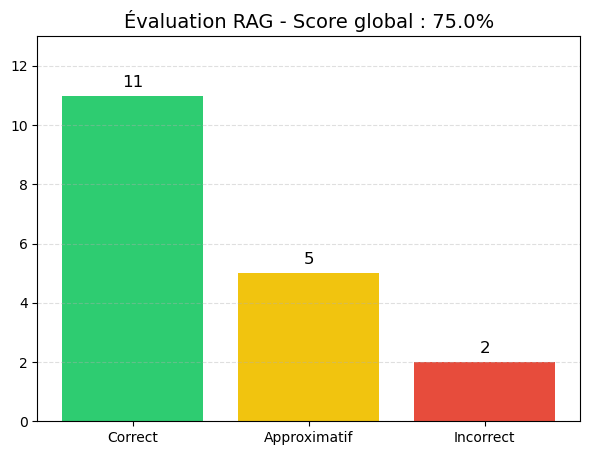

In [642]:
import matplotlib.pyplot as plt

def evaluate_rag(answers):
    correct = 0
    approx = 0
    wrong = 0

    for _, result in answers.items():
        status = result.get("label", "wrong")

        if status == "correct":
            correct += 1
        elif status == "approx":
            approx += 1
        else:
            wrong += 1

    total = correct + approx + wrong

    score = (correct + 0.5 * approx) / total

    return {
        "correct": correct,
        "approx": approx,
        "wrong": wrong,
        "total": total,
        "score": score
    }
    results = {
    1: {"label": "correct"},
    2: {"label": "correct"},
    3: {"label": "correct"},
    4: {"label": "approx"},
    5: {"label": "correct"},
    6: {"label": "correct"},
    7: {"label": "correct"},
    8: {"label": "correct"},
    9: {"label": "correct"},
    10: {"label": "correct"},
    11: {"label": "correct"},
    12: {"label": "approx"},
    13: {"label": "approx"},
    14: {"label": "approx"},
    15: {"label": "correct"},
    16: {"label": "approx"},
    17: {"label": "wrong"},
    18: {"label": "wrong"}
}

report = evaluate_rag(results)
print(report)
def plot_rag_report(report):
    labels = ["Correct", "Approximatif", "Incorrect"]
    values = [report["correct"], report["approx"], report["wrong"]]

    colors = ["#2ecc71", "#f1c40f", "#e74c3c"]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values, color=colors)

    # annotations
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.2,
            str(height),
            ha="center",
            va="bottom",
            fontsize=12
        )

    plt.title(
        f"Évaluation RAG - Score global : {report['score']*100:.1f}%",
        fontsize=14
    )

    plt.ylim(0, max(values) + 2)
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.show()


plot_rag_report(report)

In [8]:
import mistralai.client

dir(mistralai.client)

['Any',
 'AsyncHttpClient',
 'BaseSDK',
 'Callable',
 'ClientOwner',
 'Dict',
 'Field',
 'HttpClient',
 'Logger',
 'Mistral',
 'OPENAPI_DOC_VERSION',
 'Optional',
 'OptionalNullable',
 'RetryConfig',
 'SDKConfiguration',
 'SDKHooks',
 'SERVERS',
 'SERVER_EU',
 'SPEAKEASY_GENERATOR_VERSION',
 'TYPE_CHECKING',
 'Tuple',
 'UNSET',
 'USER_AGENT',
 'Union',
 'VERSION',
 '__annotations__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__gen_version__',
 '__loader__',
 '__name__',
 '__openapi_doc_version__',
 '__package__',
 '__path__',
 '__spec__',
 '__title__',
 '__user_agent__',
 '__version__',
 '_hooks',
 '_version',
 'basesdk',
 'cast',
 'close_clients',
 'dataclass',
 'errors',
 'get_default_logger',
 'httpclient',
 'httpx',
 'importlib',
 'models',
 'models_',
 'remove_suffix',
 'sdk',
 'sdkconfiguration',
 'sys',
 'types',
 'utils',
 'weakref']

In [10]:
from mistralai.client import Mistral

client = Mistral(api_key="test")

In [6]:
from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(
    api_key="UAsxf4orVcokgaPWfBZ5VLONmWiSPxXn",
    model="mistral-small-latest"
)

print(llm)

metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '0.1.20', 'langchain-mistralai': '1.1.6'}} output_version=None profile={'name': 'Mistral Small (latest)', 'release_date': '2026-03-16', 'last_updated': '2026-03-16', 'open_weights': True, 'max_input_tokens': 256000, 'max_output_tokens': 256000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': True, 'temperature': True} client=<httpx.Client object at 0x0000026B42F9BC50> async_client=<httpx.AsyncClient object at 0x0000026B2A771F40> mistral_api_key=SecretStr('**********') endpoint='https://api.mistral.ai/v1' model='mistral-small-latest' model_kwargs={}


In [8]:
import os
from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(
    api_key=os.getenv("MISTRAL_API_KEY"),
    model="mistral-small-latest"
)

print("OK")

OK


In [12]:
from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(
    model="mistral-small-latest",
    api_key="UAsxf4orVcokgaPWfBZ5VLONmWiSPxXn"
)

In [15]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("MISTRAL_API_KEY")